In [1]:
# %pip install --upgrade pip
# %pip install pandas
# %pip install scikit-learn
# %pip install tensorflow
# %pip install keras
# %pip install matplotlib
# %pip install ipympl

In [2]:
import os
import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import load_model
from keras.callbacks import EarlyStopping
from keras import metrics
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Nadam
from tensorflow.keras.regularizers import l2
import gc
import pickle
import pandas as pd
import numpy as np
%matplotlib inline
# %matplotlib widget
import matplotlib.pyplot as plt

2025-09-02 00:19:58.438069: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-02 00:20:02.154570: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756783203.208147  997991 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756783203.358203  997991 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756783205.431170  997991 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Lista de hardware para IA

In [3]:
from tensorflow.python.client import device_lib

print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 2888337098849619682
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 10182721536
locality {
  bus_id: 1
  links {
  }
}
incarnation: 9039662829853078525
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6"
xla_global_id: 416903419
]


I0000 00:00:1756783224.702220  997991 gpu_device.cc:2019] Created device /device:GPU:0 with 9711 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Carregando os dados do sensor 1

In [4]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [5]:
# Carregar os dados do arquivo
file_path = './Dados/dados.txt'
df = pd.read_csv(file_path, header=None, names=['X', 'Y', 'Z'])
# df = df[1300:700000]
df = df[1300:1300000]
print(len(df))
print(df[:10])

1298700
             X         Y          Z
1300 -1.781370  0.741914 -64.231506
1301 -1.694854  0.759592 -64.239250
1302 -1.597467  0.700346 -64.256279
1303 -1.739162  0.631860 -64.236961
1304 -1.736698  0.634045 -64.259636
1305 -1.734998  0.728971 -64.111877
1306 -1.678491  0.770313 -64.238266
1307 -1.692173  0.711976 -64.377014
1308 -1.698621  0.677731 -64.420242
1309 -1.707504  0.719441 -64.463936


Intervalo X: -16.6888427734375 a 34.93269729614258
Intervalo Y: -7.707679748535156 a 5.511822700500488
Intervalo Z: -72.52067565917969 a -27.74943351745605


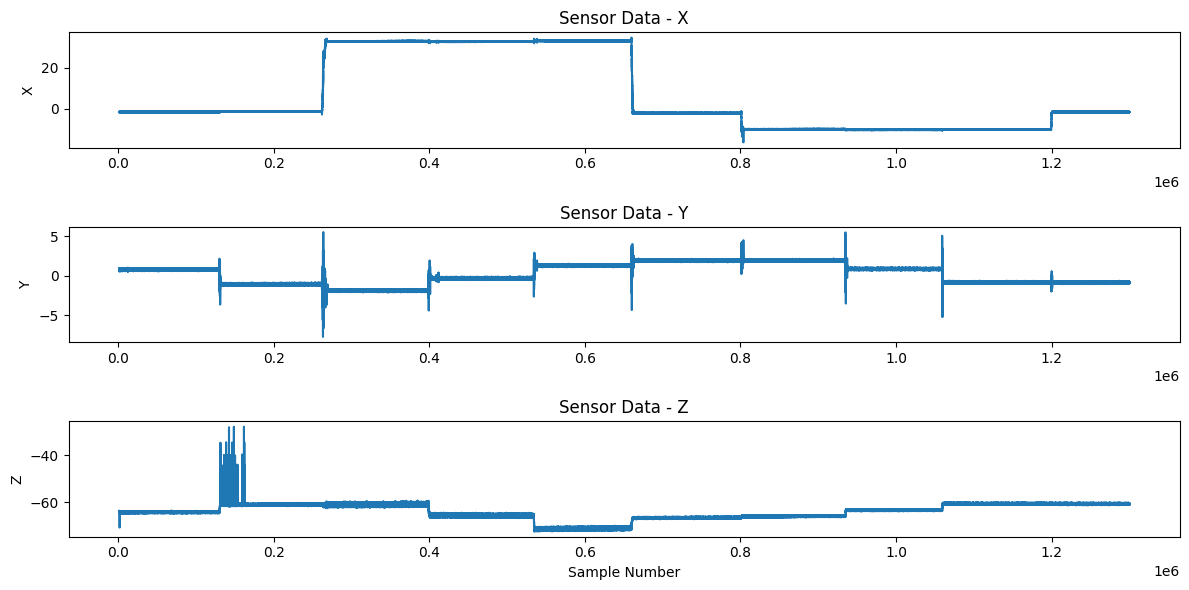

In [6]:
print(f"Intervalo X: {df['X'].min()} a {df['X'].max()}")
print(f"Intervalo Y: {df['Y'].min()} a {df['Y'].max()}")
print(f"Intervalo Z: {df['Z'].min()} a {df['Z'].max()}")


# Supondo que 'df' é seu DataFrame original com as colunas 'X', 'Y', 'Z'
plt.figure(figsize=(12, 6))

# Plotando cada coluna
plt.subplot(3, 1, 1)  # 3 linhas, 1 coluna, posição 1
plt.plot(df['X'], label='X')
plt.title('Sensor Data - X')
plt.ylabel('X')

plt.subplot(3, 1, 2)  # 3 linhas, 1 coluna, posição 2
plt.plot(df['Y'], label='Y')
plt.title('Sensor Data - Y')
plt.ylabel('Y')

plt.subplot(3, 1, 3)  # 3 linhas, 1 coluna, posição 3
plt.plot(df['Z'], label='Z')
plt.title('Sensor Data - Z')
plt.ylabel('Z')
plt.xlabel('Sample Number')

# Mostrando o gráfico
plt.tight_layout()
plt.show()


### Retirando os outliers

In [7]:
def remove_outliers_rolling_mad(df, columns, window=2000, k=6):
    mask_all = pd.Series(True, index=df.index)
    for col in columns:
        med = df[col].rolling(window, center=True).median()
        mad = (df[col] - med).abs().rolling(window, center=True).median() * 1.4826
        mask = ((df[col] - med).abs() <= k*mad).fillna(True)
        mask_all &= mask
    return df[mask_all]
# se k menor = mais agressivo
df_cleaned = remove_outliers_rolling_mad(df, ['X','Y','Z'], window=5000, k=6)
# Exibir as primeiras linhas do DataFrame limpo
print(df_cleaned.head())


             X         Y          Z
6300 -1.728978  0.804295 -64.236565
6301 -1.727947  0.823530 -64.243980
6302 -1.688770  0.835619 -64.357346
6303 -1.690171  0.833158 -64.411293
6304 -1.710678  0.793233 -64.402336


Intervalo X: -10.749733924865724 a 33.76358413696289
Intervalo Y: -2.500528335571289 a 2.415865898132324
Intervalo Z: -72.52067565917969 a -59.322635650634766


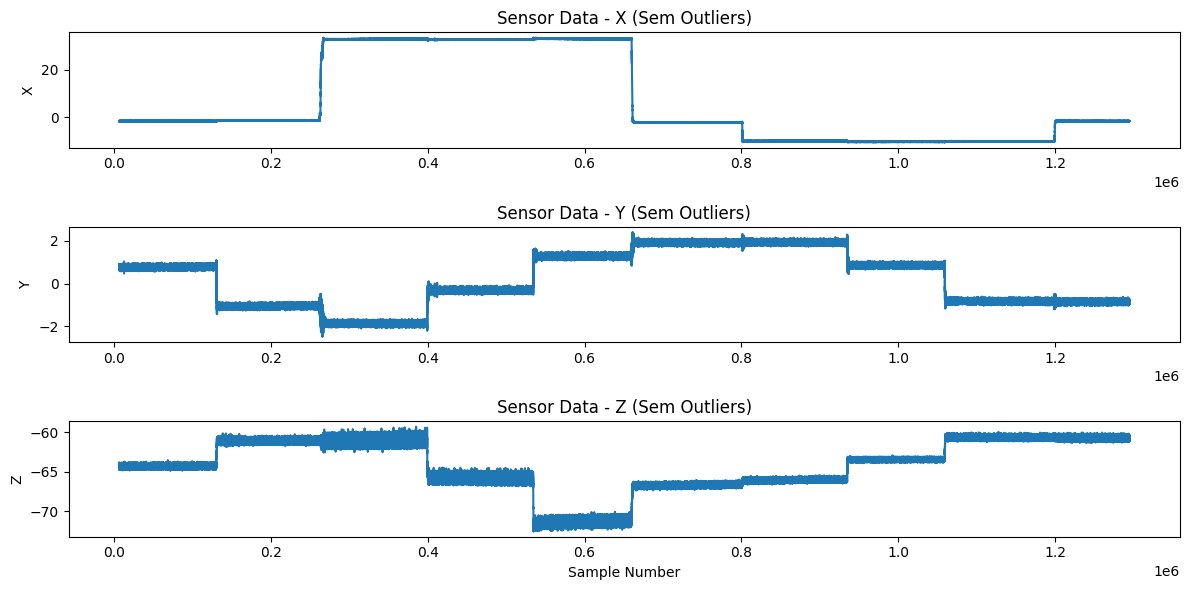

In [8]:
print(f"Intervalo X: {df_cleaned['X'].min()} a {df_cleaned['X'].max()}")
print(f"Intervalo Y: {df_cleaned['Y'].min()} a {df_cleaned['Y'].max()}")
print(f"Intervalo Z: {df_cleaned['Z'].min()} a {df_cleaned['Z'].max()}")

plt.figure(figsize=(12, 6))

# Plotar os dados após a remoção de outliers
plt.subplot(3, 1, 1)
plt.plot(df_cleaned['X'], label='X')
plt.title('Sensor Data - X (Sem Outliers)')
plt.ylabel('X')

plt.subplot(3, 1, 2)
plt.plot(df_cleaned['Y'], label='Y')
plt.title('Sensor Data - Y (Sem Outliers)')
plt.ylabel('Y')

plt.subplot(3, 1, 3)
plt.plot(df_cleaned['Z'], label='Z')
plt.title('Sensor Data - Z (Sem Outliers)')
plt.ylabel('Z')
plt.xlabel('Sample Number')

plt.tight_layout()
plt.show()

# POR ENQUANDO IGNORE A RETIRADA DOS OUTLIERS

In [9]:
# COMENTEQUE QUISER QUE IGNORE A RETIRADA DOS OUTLIERS
df=df_cleaned

## Normalizando os dados para uso do LSTM

In [10]:
# Definindo o range para -1 a 1, apropriado para sensores com valores entre -180 e 180
# scaler = MinMaxScaler(feature_range=(-1, 1))
# scaler = StandardScaler()

# Normalizando os dados
# df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# Salvando o scaler ajustado
# with open('scaler.pkl', 'wb') as f:
#     pickle.dump(scaler, f)

# Visualizando os primeiros dados normalizados
# print(df_scaled.head())
def normalizar_eixos_independente(dataframe):
    """
    Normaliza as colunas 'X', 'Y' e 'Z' de um DataFrame individualmente 
    com MinMaxScaler no intervalo (-1, 1).

    Retorna:
        df_scaled: DataFrame normalizado
        scalers: dicionário com os scalers {'X': scaler_X, 'Y': scaler_Y, 'Z': scaler_Z}
    """
    scaler_X = MinMaxScaler(feature_range=(-1, 1))
    scaler_Y = MinMaxScaler(feature_range=(-1, 1))
    scaler_Z = MinMaxScaler(feature_range=(-1, 1))

    df_scaled = pd.DataFrame()
    df_scaled['X'] = scaler_X.fit_transform(dataframe[['X']]).flatten()
    df_scaled['Y'] = scaler_Y.fit_transform(dataframe[['Y']]).flatten()
    df_scaled['Z'] = scaler_Z.fit_transform(dataframe[['Z']]).flatten()

    scalers = {'X': scaler_X, 'Y': scaler_Y, 'Z': scaler_Z}
    return df_scaled, scalers

df_scaled, scalers_tuple = normalizar_eixos_independente(df)


# # Salvar os scalers em um único arquivo (como uma tupla)
with open('scalers.pkl', 'wb') as f:
    pickle.dump(scalers_tuple, f)

# # Visualizando os primeiros dados normalizados
print(df_scaled.head())


          X         Y         Z
0 -0.594694  0.344409  0.255355
1 -0.594648  0.352234  0.254231
2 -0.592888  0.357152  0.237052
3 -0.592950  0.356151  0.228877
4 -0.593872  0.339909  0.230234


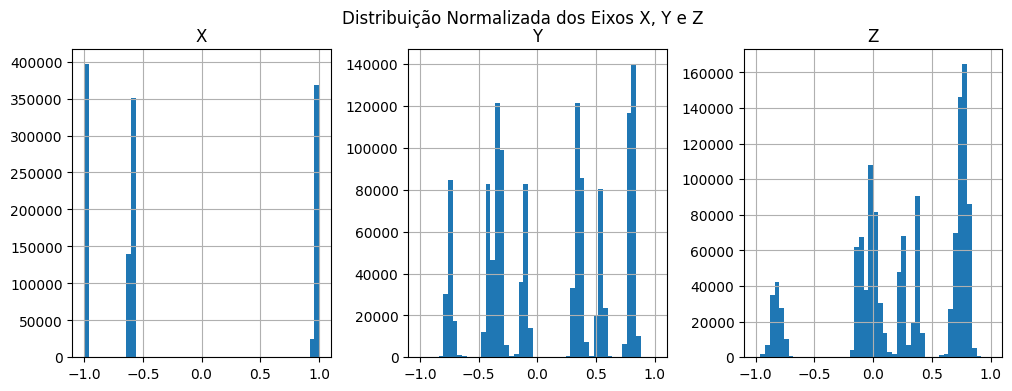

In [11]:
# Histogramas dos valores normalizados

df_scaled.hist(bins=50, figsize=(12, 4), layout=(1, 3))
plt.suptitle("Distribuição Normalizada dos Eixos X, Y e Z")
plt.show()

Intervalo X: -1.0 a 1.0
Intervalo Y: -1.0 a 1.0
Intervalo Z: -1.0 a 1.0


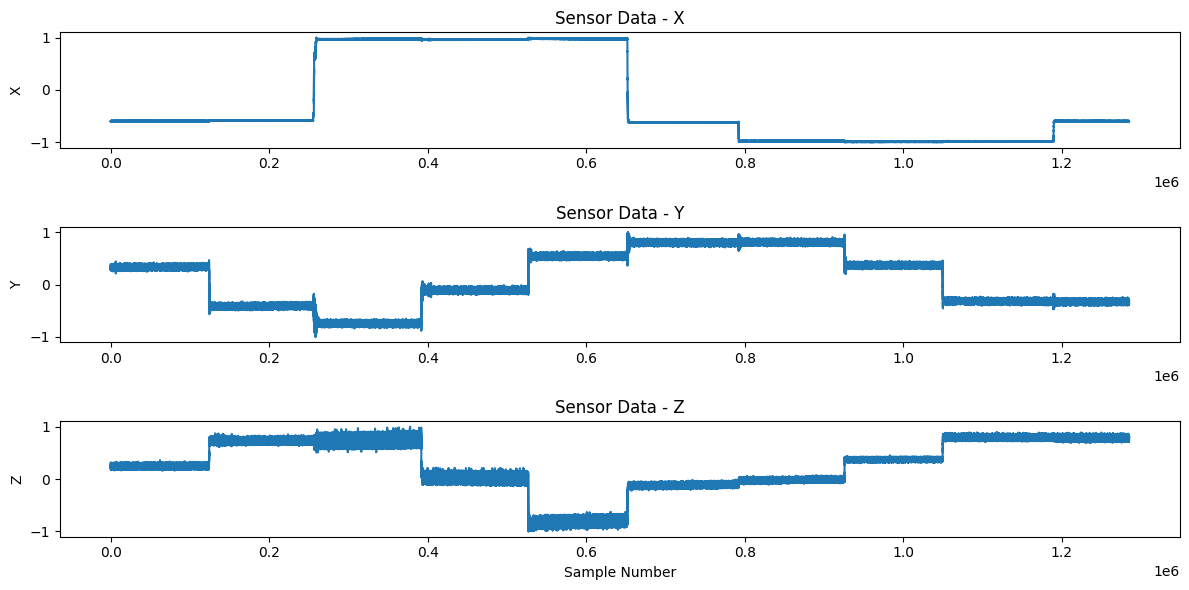

In [12]:
print(f"Intervalo X: {df_scaled['X'].min()} a {df_scaled['X'].max()}")
print(f"Intervalo Y: {df_scaled['Y'].min()} a {df_scaled['Y'].max()}")
print(f"Intervalo Z: {df_scaled['Z'].min()} a {df_scaled['Z'].max()}")


# Supondo que 'df' é seu DataFrame original com as colunas 'X', 'Y', 'Z'
plt.figure(figsize=(12, 6))

# Plotando cada coluna
plt.subplot(3, 1, 1)  # 3 linhas, 1 coluna, posição 1
plt.plot(df_scaled['X'], label='X')
plt.title('Sensor Data - X')
plt.ylabel('X')

plt.subplot(3, 1, 2)  # 3 linhas, 1 coluna, posição 2
plt.plot(df_scaled['Y'], label='Y')
plt.title('Sensor Data - Y')
plt.ylabel('Y')

plt.subplot(3, 1, 3)  # 3 linhas, 1 coluna, posição 3
plt.plot(df_scaled['Z'], label='Z')
plt.title('Sensor Data - Z')
plt.ylabel('Z')
plt.xlabel('Sample Number')

# Mostrando o gráfico
plt.tight_layout()
plt.show()

# ******************************************************
# HIPERPARAMETROS

In [13]:
# Valores dos hiperparâmetros
n_splits=4 # 4
timestepsValue = 80 # 80
pesosValue = tf.constant([ 1.0, 1.0, 1.0]) # ([1.0, 0.1, 1.0])
neuroniosValue = 350 # 350                                                                                                                                                                                                                                 # 25
dropoutValue = 0.14512369139123038
ativacaoType = 'tanh'
best_lr = 0.0019702991167906115
epocasValue = 50 # 50
batchValue = 600 # 300
pacienciaValue = 10 # 10

# Criar uma pasta para salvar os modelos
model_folder = "models_GY87"
os.makedirs(model_folder, exist_ok=True)

# Dicionário com os hiperparâmetros
experiment_config = {
    "Splits": n_splits,
    "timesteps": timestepsValue,
    "wights": pesosValue.numpy().tolist(),
    "neuronios": neuroniosValue,
    "dropout": dropoutValue,
    "ativacao": ativacaoType,
    "learning_rate": best_lr,
    "epocas": epocasValue,
    "batch": batchValue,
    "paciencia": pacienciaValue
}

# Salvar os hiperparâmetros em um arquivo JSON
import json
config_path = os.path.join(model_folder, "hiperparametros.json")
with open(config_path, "w") as f:
    json.dump(experiment_config, f, indent=4)

print(f"Hiperparâmetros salvos em {config_path}")

Hiperparâmetros salvos em models_GY87/hiperparametros.json


I0000 00:00:1756783231.315812  997991 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9711 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


## Definindo Cross Validation TimeSeriesSplit e Variáveis

In [14]:
# Função de perda ponderada (se quiser usar)
def weighted_mse_with_bias(y_true, y_pred):
    weights = pesosValue  # Tensor com shape (3,)
    mse = K.mean(weights * K.square(y_pred - y_true), axis=-1)
    bias = K.square(K.mean(y_true - y_pred, axis=0)) * weights # penaliza viés médio
    return mse + 1.0 * K.sum(bias)  # Ajuste o fator conforme a sensibilidade


# Função para monitorar o erro em cada eixo separadamente durante o treinamento.
# Assim, você pode ver se o modelo está realmente aprendendo em todos os eixos.
def mse_x(y_true, y_pred):
    return K.mean(K.square(y_pred[:, 0] - y_true[:, 0]))

def mse_y(y_true, y_pred):
    return K.mean(K.square(y_pred[:, 1] - y_true[:, 1]))

def mse_z(y_true, y_pred):
    return K.mean(K.square(y_pred[:, 2] - y_true[:, 2]))


tscv = TimeSeriesSplit(n_splits)
print(tscv)

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=4, test_size=None)


## Criar Sequências para Treino e Teste
### Transformando os dados de treino e teste em sequências temporais para serem usados como entrada no modelo LSTM.

In [15]:
# # Função para criar sequências
def create_sequences(data, n_timesteps):
    X, y = [], []
    for i in range(len(data) - n_timesteps):
        X.append(data[i:i+n_timesteps, :])  # Sequência de entrada
        y.append(data[i+n_timesteps, :])   # Próxima linha como saída
    return np.array(X), np.array(y)

# Definir o número de timesteps (janelas de tempo)
n_timesteps = timestepsValue  # Exemplo: 80 passos no tempo
n_features = df_scaled.shape[1]  # Número de colunas (X, Y, Z)


In [16]:
# Visualizar os splits gerados
for train_index, test_index in tscv.split(df_scaled):
    print(f"Treino: {len(train_index)} amostras, Teste: {len(test_index)} amostras")
    print(f"Treino: {train_index[:5]}...{train_index[-5:]}, Teste: {test_index[:5]}...{test_index[-5:]}")

Treino: 256976 amostras, Teste: 256974 amostras
Treino: [0 1 2 3 4]...[256971 256972 256973 256974 256975], Teste: [256976 256977 256978 256979 256980]...[513945 513946 513947 513948 513949]
Treino: 513950 amostras, Teste: 256974 amostras
Treino: [0 1 2 3 4]...[513945 513946 513947 513948 513949], Teste: [513950 513951 513952 513953 513954]...[770919 770920 770921 770922 770923]
Treino: 770924 amostras, Teste: 256974 amostras
Treino: [0 1 2 3 4]...[770919 770920 770921 770922 770923], Teste: [770924 770925 770926 770927 770928]...[1027893 1027894 1027895 1027896 1027897]
Treino: 1027898 amostras, Teste: 256974 amostras
Treino: [0 1 2 3 4]...[1027893 1027894 1027895 1027896 1027897], Teste: [1027898 1027899 1027900 1027901 1027902]...[1284867 1284868 1284869 1284870 1284871]


### Caso não queira treinar novamente, mas apenas executar a predição do modelo, descomente!

In [17]:
# Loop de treinamento para cada split
# for split_idx, (train_index, test_index) in enumerate(tscv.split(df_scaled.values), start=1):
#     # Criar os dados de treino e teste
#     train_data, test_data = df_scaled.values[train_index], df_scaled.values[test_index]
#     X_train, y_train = create_sequences(train_data, n_timesteps)
#     X_test, y_test = create_sequences(test_data, n_timesteps)
    
#     print(f"Split {split_idx}:")
#     print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
#     print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# LSTM

### Treinar o Modelo em Cada Split usando o Early Stopping e Salvando .keras
Para cada split será treinado o modelo usando os dados de treino e será avaliado nos dados de teste. O EarlyStopping será usado para evitar overfitting.

In [18]:
# Loop de treinamento para cada split
for split_idx, (train_index, test_index) in enumerate(tscv.split(df_scaled.values), start=1):
    # Limpeza de memória antes de iniciar o próximo modelo
    K.clear_session()
    gc.collect()
    # Criar os dados de treino e teste
    train_data, test_data = df_scaled.values[train_index], df_scaled.values[test_index]
    X_train, y_train = create_sequences(train_data, n_timesteps)
    X_test, y_test = create_sequences(test_data, n_timesteps)
    
    print(f"Split {split_idx}:")
    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

    # Configurar o modelo LSTM
    model = Sequential()
    model.add(Input(shape=(n_timesteps, n_features)))
    # Se quiser 4 camadas LSTM, descomente as linhas abaixo:
    # model.add(LSTM(units=270, activation='tanh', return_sequences=True))
    # model.add(LSTM(units=150, activation='tanh', return_sequences=True))
    # model.add(LSTM(units=150, activation='tanh', return_sequences=True))
    # model.add(LSTM(units=150, activation=ativacaoType))
    # Se quiser só 1 camada LSTM, use apenas a linha abaixo:
    # model.add(LSTM(units=neuroniosValue, activation=ativacaoType, kernel_regularizer=l2(0.001)))
    model.add(LSTM(units=neuroniosValue, activation=ativacaoType))
    # model.add(Dropout(dropoutValue))
    model.add(Dense(n_features))
    
    model.compile(
        optimizer = 'Nadam', # Nadam(learning_rate=best_lr),
        loss = 'mse', #weighted_mse_with_bias,
        metrics=[
            metrics.MeanSquaredError(),
            metrics.MeanAbsoluteError(),
            metrics.RootMeanSquaredError(),
            mse_x, mse_y, mse_z  # métricas customizadas
        ]
    )

    # Treinar o modelo
    print(f"Treinando o modelo para o split {split_idx}...")
    history = model.fit(
        X_train, y_train,
        epochs=epocasValue,
        batch_size=batchValue,
        validation_data=(X_test, y_test),
        callbacks=[EarlyStopping(monitor='val_loss', patience=pacienciaValue, verbose=1, mode='min')],
        verbose=1
    )

    # Salvar o modelo no formato .keras
    model_path = os.path.join(model_folder, f"lstm_split_{split_idx}.keras")
    model.save(model_path)
    print(f"Modelo do split {split_idx} salvo em {model_path}")

Split 1:
X_train shape: (256896, 80, 3), y_train shape: (256896, 3)
X_test shape: (256894, 80, 3), y_test shape: (256894, 3)
Treinando o modelo para o split 1...
Epoch 1/50


I0000 00:00:1756783239.203350  998154 cuda_dnn.cc:529] Loaded cuDNN version 90501


429/429 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - loss: 0.0103 - mean_absolute_error: 0.0382 - mean_squared_error: 0.0103 - mse_x: 0.0108 - mse_y: 0.0069 - mse_z: 0.0130 - root_mean_squared_error: 0.0822 - val_loss: 0.0030 - val_mean_absolute_error: 0.0442 - val_mean_squared_error: 0.0030 - val_mse_x: 0.0032 - val_mse_y: 0.0032 - val_mse_z: 0.0026 - val_root_mean_squared_error: 0.0550
Epoch 2/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 24s 56ms/step - loss: 3.8408e-04 - mean_absolute_error: 0.0135 - mean_squared_error: 3.8408e-04 - mse_x: 2.9801e-05 - mse_y: 5.6632e-04 - mse_z: 5.5611e-04 - root_mean_squared_error: 0.0196 - val_loss: 0.0045 - val_mean_absolute_error: 0.0520 - val_mean_squared_error: 0.0045 - val_mse_x: 8.0304e-04 - val_mse_y: 0.0092 - val_mse_z: 0.0036 - val_root_mean_squared_error: 0.0673
Epoch 3/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 24s 56ms/step - loss: 3.7612e-04 - mean_absolute_error: 0.0133 - mean_squared_error: 3.7612e-04 - mse_x: 2.4796e-05 - mse_y: 5.7388e-04 - mse_z: 5.2968e-04 - r

### Salvar o Histórico do Treinamento (history.json)

In [19]:
import json

# Criar uma pasta para salvar os modelos
model_folder = "models_GY87"
config_path = os.path.join(model_folder, "history.json")
# Salvar o histórico do treinamento em um arquivo JSON
with open(config_path, "w") as f:
    json.dump(history.history, f)

### Carregar o Histórico (history.json)

In [20]:
import json

model_folder = "models_GY87"
config_path = os.path.join(model_folder, "history.json")
# Carregar o histórico salvo
with open(config_path, "r") as f:
    loaded_history = json.load(f)

# Exemplo de acesso aos dados carregados
print("Chaves do histórico:", loaded_history.keys())
print("Perda final:", loaded_history["loss"][-1])
print("Validação final:", loaded_history["val_loss"][-1])


Chaves do histórico: dict_keys(['loss', 'mean_absolute_error', 'mean_squared_error', 'mse_x', 'mse_y', 'mse_z', 'root_mean_squared_error', 'val_loss', 'val_mean_absolute_error', 'val_mean_squared_error', 'val_mse_x', 'val_mse_y', 'val_mse_z', 'val_root_mean_squared_error'])
Perda final: 0.00028298210236243904
Validação final: 0.0014293442945927382


### Visualizar o Histórico de Treinamento

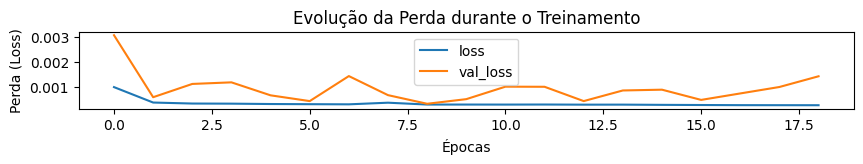

In [21]:
import matplotlib.pyplot as plt

# Plotando a perda de treino e validação
plt.figure(figsize=(10,1))
plt.plot(loaded_history["loss"], label="loss")
plt.plot(loaded_history["val_loss"], label="val_loss")
plt.xlabel("Épocas")
plt.ylabel("Perda (Loss)")
plt.title("Evolução da Perda durante o Treinamento")
plt.legend()
plt.show()


# Avaliar o Modelo ******************************
#### Após o treinamento de cada split, é avaliado o desempenho do modelo no conjunto de teste.

In [22]:
import sys
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
import pickle

# Função para criar sequências
def create_sequences(data, n_timesteps):
    X, y = [], []
    for i in range(len(data) - n_timesteps):
        X.append(data[i:(i + n_timesteps)])
        y.append(data[i + n_timesteps])
    return np.array(X), np.array(y)

# Classe Tee para duplicar a saída (console e arquivo)
class Tee:
    def __init__(self, *files):
        self.files = files
        self.encoding = getattr(files[0], 'encoding', 'utf-8')
    def write(self, obj):
        for f in self.files:
            f.write(obj)
    def flush(self):
        for f in self.files:
            f.flush()

# Carregar dados e scaler
# print("Carregando dados...")
# file_path = './Dados/dados.txt'
# df = pd.read_csv(file_path, header=None, names=['X', 'Y', 'Z'])
# df = df[1300:1001300]

# Carregar o scaler
# with open('scaler.pkl', 'rb') as f:
#     scaler = pickle.load(f)

# Diretório onde salvar os resultados
model_folder = "models_GY87"
os.makedirs(model_folder, exist_ok=True)

# Arquivo de log para salvar o output com a mesma estrutura
log_path = os.path.join(model_folder, "evaluation.log")

# Abrir o arquivo com encoding 'utf-8' para evitar erros de caracteres
with open(log_path, "w", encoding="utf-8") as log_file:
    # Redireciona a saída padrão para imprimir tanto no console quanto no arquivo
    original_stdout = sys.stdout
    sys.stdout = Tee(original_stdout, log_file)
    
    print("Iniciando avaliação dos modelos...")
    
    # Inicializar lista para métricas
    results = []
    
    # Avaliar os modelos salvos
    for split_idx, (train_index, test_index) in enumerate(tscv.split(df_scaled.values), start=1):
        print(f"\n=== Avaliando Split {split_idx} ===")
        
        # Carregar o modelo salvo
        model_path = os.path.join(model_folder, f"lstm_split_{split_idx}.keras")
        
        if not os.path.exists(model_path):
            print(f"Modelo {model_path} não encontrado. Pulando...")
            continue
            
        try:
            model = load_model(model_path, custom_objects={
                "weighted_mse_with_bias": weighted_mse_with_bias,
                "mse_x": mse_x,
                "mse_y": mse_y,
                "mse_z": mse_z
            })
            print(f"Modelo carregado: {model_path}")
        except Exception as e:
            print(f"Erro ao carregar modelo {model_path}: {e}")
            continue
        
        # Criar os dados de teste
        test_data = df_scaled.values[test_index]
        X_test, y_test = create_sequences(test_data, n_timesteps)
        
        print(f"Dados de teste - X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
        
        # Validar shapes dos dados
        assert X_test.shape[0] == y_test.shape[0], "Número de exemplos em X_test e y_test não coincidem!"
        assert X_test.shape[1] == n_timesteps, "Número de timesteps em X_test está incorreto!"
        assert X_test.shape[2] == n_features, "Número de features em X_test está incorreto!"
        
        # Temporariamente restaura a saída padrão para evitar que o progress bar seja capturado no log
        temp_stdout = sys.stdout
        sys.stdout = original_stdout
        
        print(f"Fazendo predições para o split {split_idx}...")
        # Fazer previsões (verbose=1 para exibir o progress bar no console)
        y_pred = model.predict(X_test, verbose=1)
        
        # Após a predição, volta a redirecionar a saída para o nosso Tee
        sys.stdout = temp_stdout
        
        print(f"Predições concluídas - shape: {y_pred.shape}")
        
        # Cálculo das métricas
        mse_total = mean_squared_error(y_test, y_pred)
        r2_total = r2_score(y_test, y_pred)
        mse_x_val = mean_squared_error(y_test[:, 0], y_pred[:, 0])
        r2_x = r2_score(y_test[:, 0], y_pred[:, 0])
        mse_y_val = mean_squared_error(y_test[:, 1], y_pred[:, 1])
        r2_y = r2_score(y_test[:, 1], y_pred[:, 1])
        mse_z_val = mean_squared_error(y_test[:, 2], y_pred[:, 2])
        r2_z = r2_score(y_test[:, 2], y_pred[:, 2])
        
        # Salvando métricas
        results.append({
            'split': split_idx,
            'mse_total': mse_total, 'r2_total': r2_total,
            'mse_x': mse_x_val, 'r2_x': r2_x,
            'mse_y': mse_y_val, 'r2_y': r2_y,
            'mse_z': mse_z_val, 'r2_z': r2_z
        })
        
        # Imprimir output no formato desejado (sem os updates do progress bar)
        print(f"Split {split_idx} - MSE Total: {mse_total:.6f}, R² Total: {r2_total:.6f}")
        print(f"Split {split_idx} - MSE X: {mse_x_val:.6f}, R² X: {r2_x:.6f}")
        print(f"Split {split_idx} - MSE Y: {mse_y_val:.6f}, R² Y: {r2_y:.6f}")
        print(f"Split {split_idx} - MSE Z: {mse_z_val:.6f}, R² Z: {r2_z:.6f}")
    
    # Consolidar os resultados em um DataFrame
    if results:
        df_results = pd.DataFrame(results)
        
        # Salvar os resultados em CSV
        csv_path = os.path.join(model_folder, "evaluation_results.csv")
        df_results.to_csv(csv_path, index=False)
        print(f"\nResultados salvos em {csv_path}")
        
        # Calcular e exibir estatísticas resumidas
        print("\n=== RESUMO DOS RESULTADOS ===")
        print("Médias das métricas:")
        for col in df_results.columns:
            if col != 'split':
                print(f"{col}: {df_results[col].mean():.6f} ± {df_results[col].std():.6f}")
    else:
        print("Nenhum modelo foi avaliado com sucesso.")
    
    # Restaurar a saída padrão
    sys.stdout = original_stdout

print("Avaliação concluída!")

Iniciando avaliação dos modelos...

=== Avaliando Split 1 ===
Modelo carregado: models_GY87/lstm_split_1.keras
Dados de teste - X_test shape: (256894, 80, 3), y_test shape: (256894, 3)
Fazendo predições para o split 1...
8028/8028 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step
Predições concluídas - shape: (256894, 3)
Split 1 - MSE Total: 0.007174, R² Total: 0.354778
Split 1 - MSE X: 0.001151, R² X: -0.748784
Split 1 - MSE Y: 0.012913, R² Y: 0.872226
Split 1 - MSE Z: 0.007458, R² Z: 0.940892

=== Avaliando Split 2 ===
Modelo carregado: models_GY87/lstm_split_2.keras
Dados de teste - X_test shape: (256894, 80, 3), y_test shape: (256894, 3)
Fazendo predições para o split 2...
8028/8028 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step
Predições concluídas - shape: (256894, 3)
Split 2 - MSE Total: 0.113439, R² Total: -1.067595
Split 2 - MSE X: 0.002850, R² X: 0.995479
Split 2 - MSE Y: 0.241780, R² Y: -4.456406
Split 2 - MSE Z: 0.095687, R² Z: 0.258143

=== Avaliando Split 3 ===
Modelo carregado: models_GY87/lstm_spli

# Carregando o modelo desejado pelo split

In [23]:
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K

# Definindo o diretório onde o modelo está salvo
model_folder = "models_GY87"
model_path = os.path.join(model_folder, 'lstm_split_3.keras')

# Carregando o modelo com todas as funções customizadas
modelo_carregado = load_model(
    model_path, 
    custom_objects={
        "weighted_mse_with_bias": weighted_mse_with_bias,
        "mse_x": mse_x,
        "mse_y": mse_y,
        "mse_z": mse_z
    }
)

print(modelo_carregado.summary())


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 350)            │       495,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         1,053 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,489,962 (5.68 MB)

 Trainable params: 496,653 (1.89 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 993,309 (3.79 MB)

None


Fazendo previsões

In [24]:
predicted = modelo_carregado.predict(X_test)
# predicted = y_pred

8028/8028 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step


Plotando os Resultados

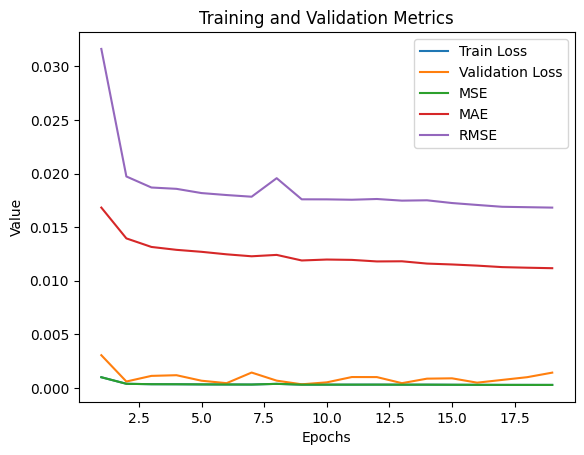

In [25]:
epochs = range(1, len(history.history['loss']) + 1)

plt.plot(epochs, history.history['loss'], label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
plt.plot(epochs, history.history['mean_squared_error'], label='MSE')
plt.plot(epochs, history.history['mean_absolute_error'], label='MAE')
plt.plot(epochs, history.history['root_mean_squared_error'], label='RMSE')
plt.title('Training and Validation Metrics')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.show()

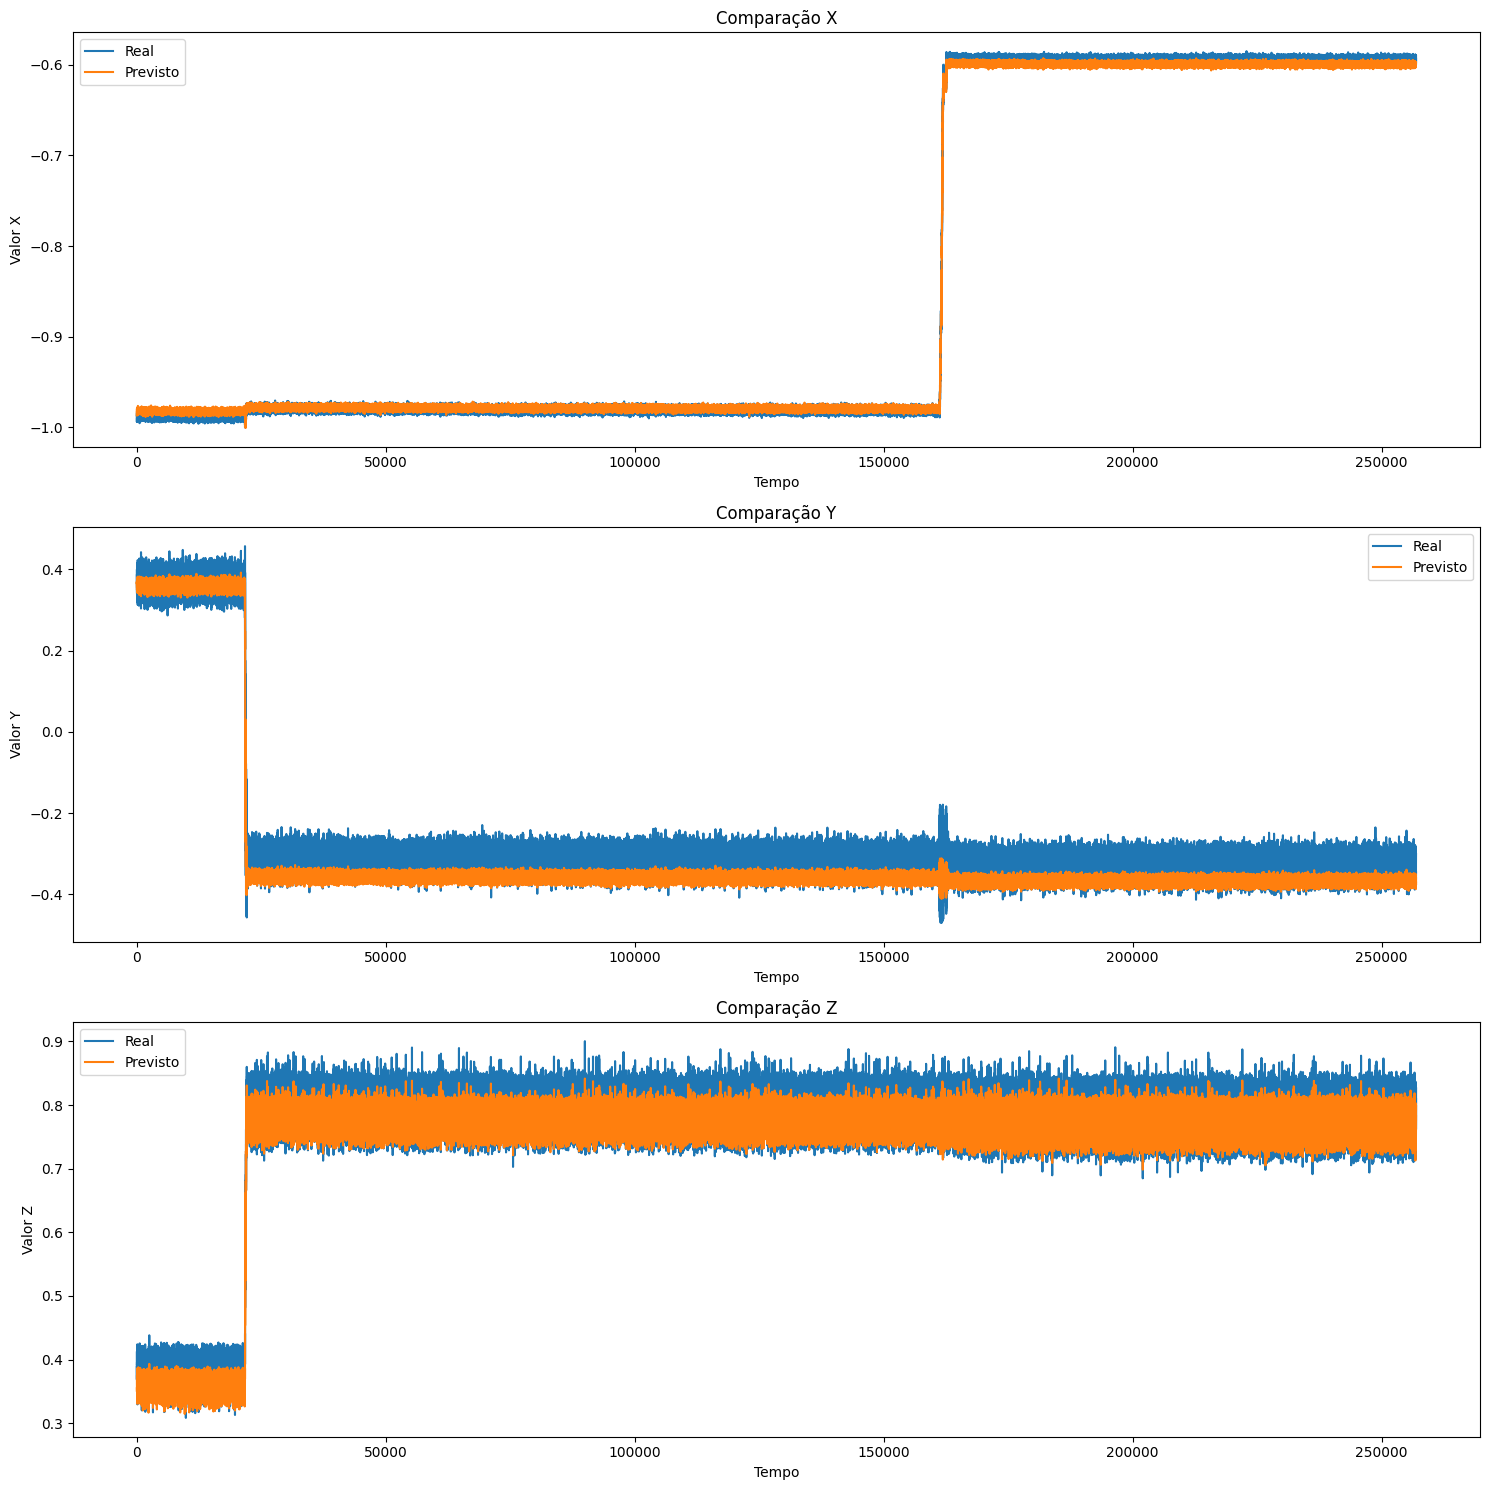

In [26]:
# Definindo as dimensões
dims = ['X', 'Y', 'Z']

plt.figure(figsize=(15, 15))

# Criando um gráfico para cada dimensão
for i, dim in enumerate(dims):
    plt.subplot(3, 1, i+1)
    plt.plot(X_test[:, -1, i], label='Real')
    plt.plot(predicted[:, i], label='Previsto')
    plt.title(f'Comparação {dim}')
    plt.xlabel('Tempo')
    plt.ylabel(f'Valor {dim}')
    plt.legend()

plt.tight_layout()
plt.show()



### Plotando desnormalizado

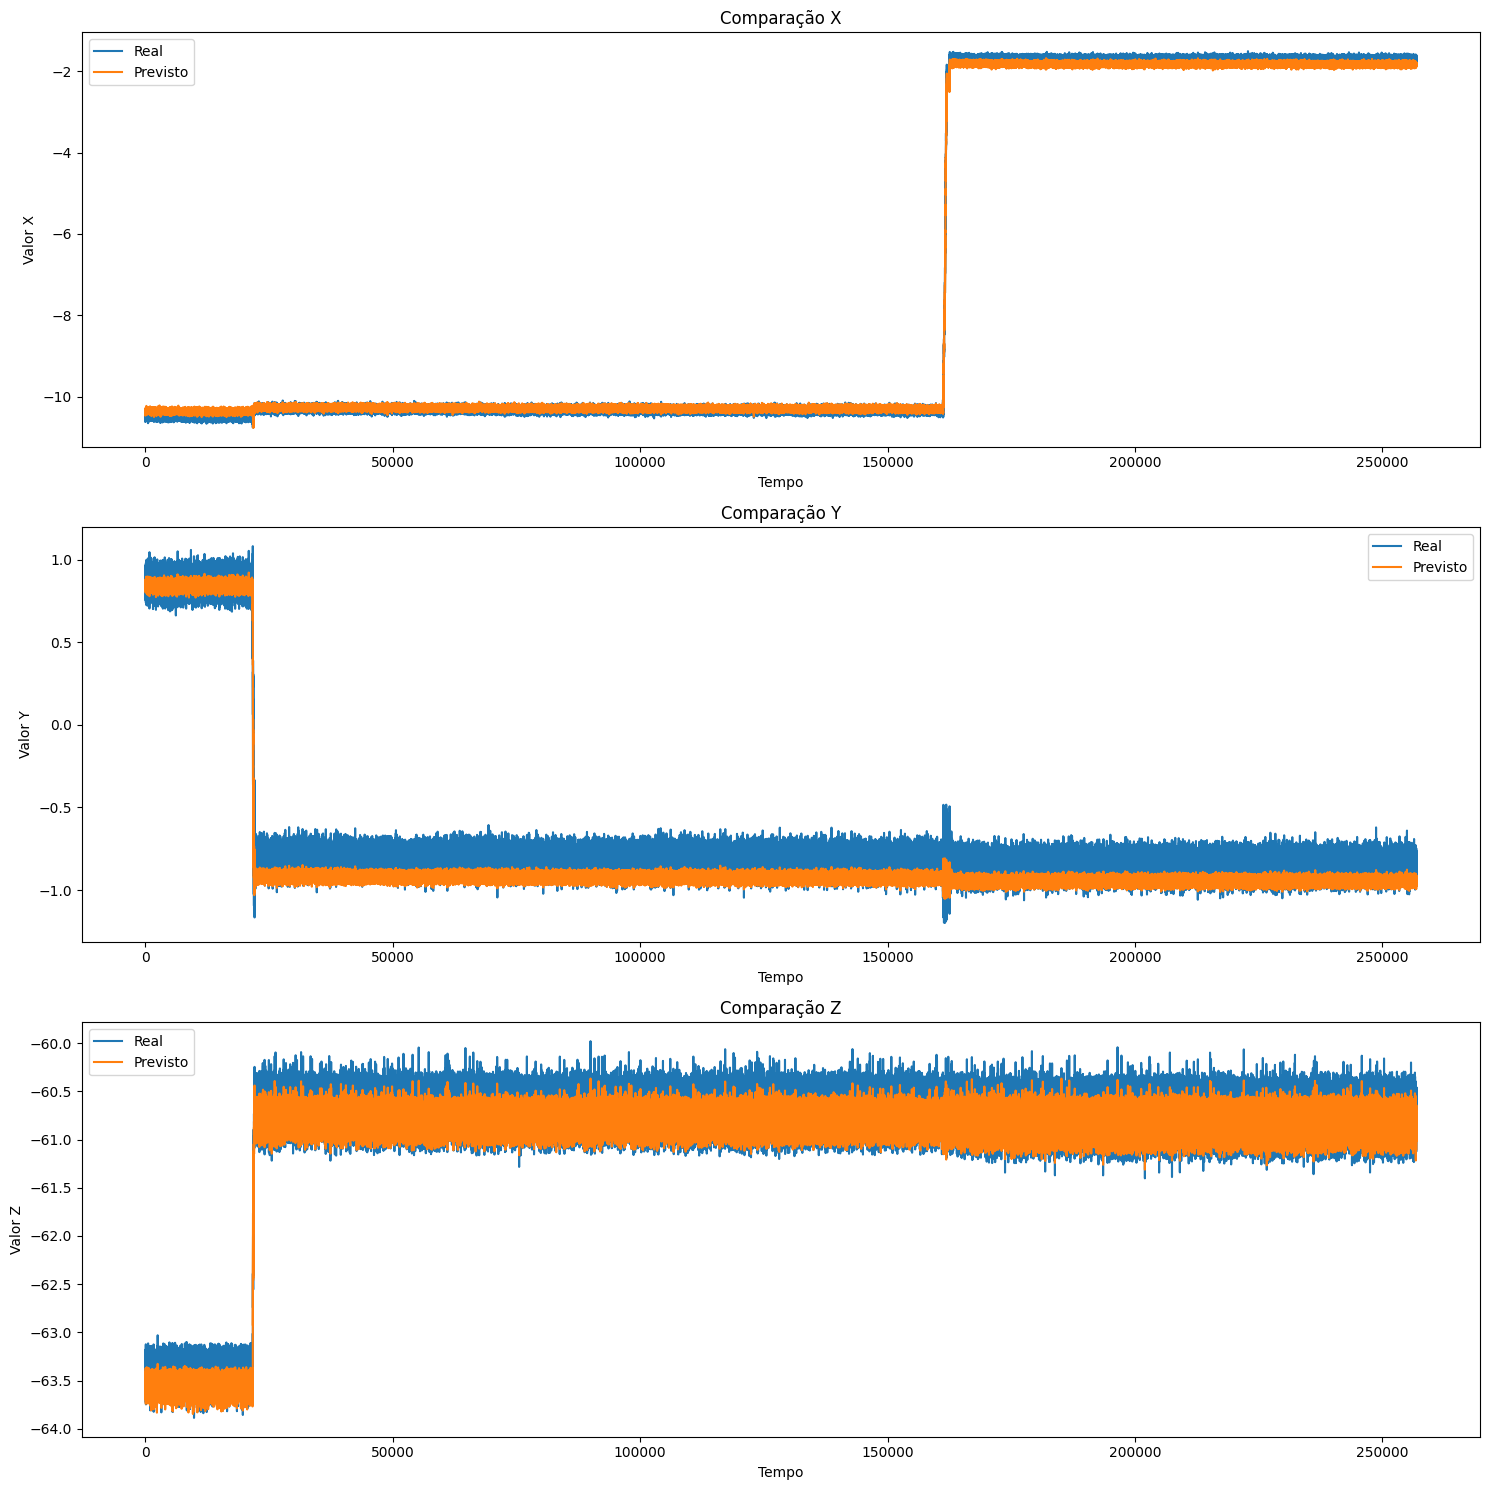

In [27]:
dims = ['X', 'Y', 'Z']

plt.figure(figsize=(15, 15))

for i, dim in enumerate(dims):
    plt.subplot(3, 1, i+1)

    # Desnormalizando os valores reais e previstos
    real_denorm = scalers_tuple[dim].inverse_transform(X_test[:, -1, i].reshape(-1, 1)).flatten()
    pred_denorm = scalers_tuple[dim].inverse_transform(predicted[:, i].reshape(-1, 1)).flatten()

    plt.plot(real_denorm, label='Real')
    plt.plot(pred_denorm, label='Previsto')
    plt.title(f'Comparação {dim}')
    plt.xlabel('Tempo')
    plt.ylabel(f'Valor {dim}')
    plt.legend()

plt.tight_layout()
plt.show()

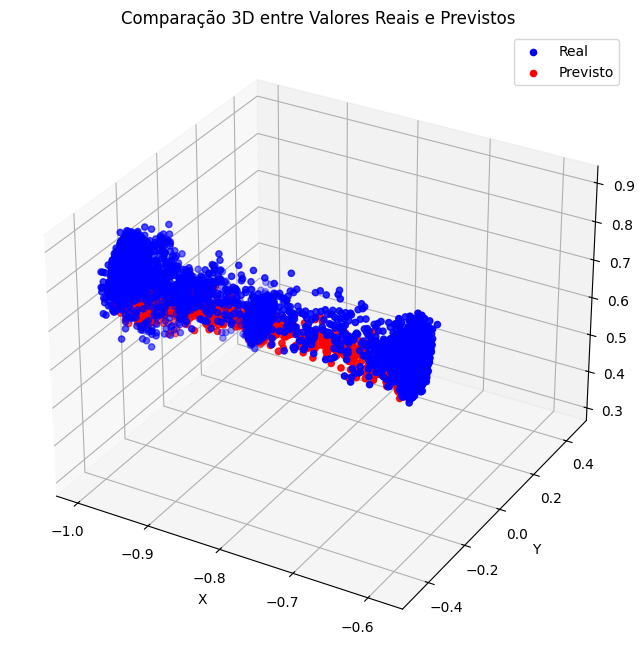

In [28]:

# Criando a figura
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotando os valores reais
ax.scatter(X_test[:, -1, 0], X_test[:, -1, 1], X_test[:, -1, 2], color='blue', label='Real')

# Plotando os valores previstos
ax.scatter(predicted[:, 0], predicted[:, 1], predicted[:, 2], color='red', label='Previsto')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title('Comparação 3D entre Valores Reais e Previstos')
plt.legend()
plt.show()



## Mean Squared Error e $R^2$

In [29]:
mse = mean_squared_error(y_test, predicted)
r2 = r2_score(y_test, predicted)

MSE_R2 = {
    "MSE: ":mse,
    "R2: ": r2
}
# Salvar os hiperparâmetros em um arquivo JSON
model_folder = "models_GY87"
config_path = os.path.join(model_folder, "1.Mean Squared Error e R2.Teste.json")
with open(config_path, "w") as f:
    json.dump(MSE_R2, f, indent=4)

print(f"Hiperparâmetros salvos em {config_path}")

print("MSE:", mse)
print("R²:", r2)

Hiperparâmetros salvos em models_GY87/1.Mean Squared Error e R2.Teste.json
MSE: 0.0007932091775003563
R²: 0.9702952260436538


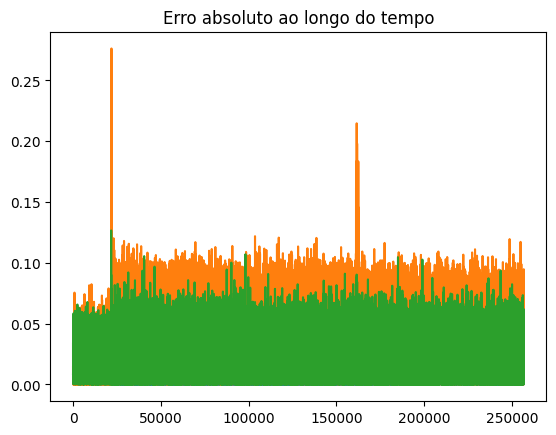

In [30]:
erro = np.abs(y_test - predicted)
plt.plot(erro)
plt.title("Erro absoluto ao longo do tempo")
plt.show()

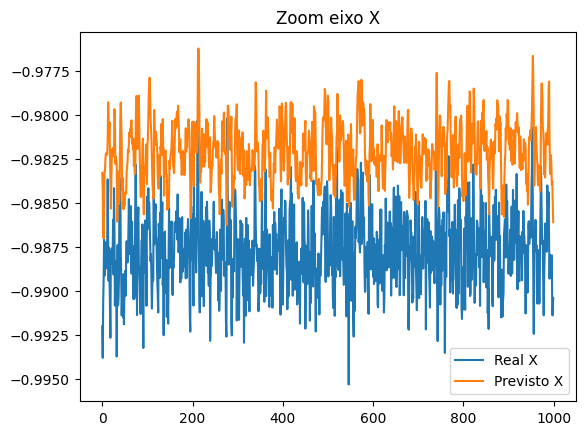

In [31]:
plt.plot(y_test[:1000, 0], label='Real X')
plt.plot(predicted[:1000, 0], label='Previsto X')
plt.legend()
plt.title("Zoom eixo X")
plt.show()

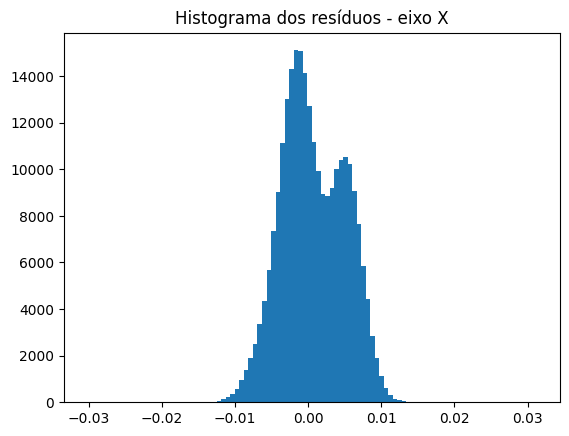

In [32]:
residuos = y_test - predicted
plt.hist(residuos[:, 0], bins=100)
plt.title("Histograma dos resíduos - eixo X")
plt.show()


In [33]:
bias = np.mean(y_test - predicted)
predicted_corrigido = predicted + bias


# _________________________________________________________________________________________________
# Teste em um NOVO conjunto de dados do mesmo sensor, o Sensor 1

Carregando Dados Sensor 1

In [34]:
# Carregar os dados do arquivo
file_path1 = './Dados/sensor_data GY-87_1.1.txt'
df1_1 = pd.read_csv(file_path1, header=None, names=['X', 'Y', 'Z'])
print(len(df1_1))
print(df1_1.head())

375151
          X          Y           Z
0 -8.789435  -8.031115 -131.726822
1 -2.515755   9.834208  -65.708527
2  0.286306  28.450745  113.858810
3 -8.749084  32.791618  172.558365
4 -7.755535  26.062883  176.409973


### Retirando Outliers

In [35]:
df_cleaned1_1 = remove_outliers_rolling_mad(df1_1, ['X','Y','Z'], window=5000, k=6)
# Exibir as primeiras linhas do DataFrame limpo
print(df_cleaned1_1.head())
df1_1=df_cleaned1_1

             X         Y          Z
5000  1.051740 -1.874325 -12.327733
5001  1.063928 -1.864345 -12.292420
5002  1.122944 -1.909463 -12.261428
5003  1.090499 -1.852442 -12.184809
5004  1.059289 -1.850853 -12.112368


Normalizando os dados

In [36]:
df1_1_scaled = normalizar_eixos_independente(df1_1)[0]

print(df1_1_scaled.head())

          X         Y         Z
0 -0.975666  0.026287 -0.680443
1 -0.974340  0.033424 -0.679672
2 -0.967917  0.001156 -0.678995
3 -0.971448  0.041937 -0.677323
4 -0.974845  0.043074 -0.675741


Preparando os dados de Teste do Sensor 1

In [37]:
# Supondo que test_data seja seu DataFrame de teste normalizado
# Convertendo para numpy array
values_test1 = df1_1_scaled.values

# Reformatando os dados para a entrada LSTM
X_test1_1, y_test1_1 = [], []
for i in range(len(values_test1) - n_timesteps):
    X_test1_1.append(values_test1[i:(i + n_timesteps), :])
    y_test1_1.append(values_test1[i + n_timesteps, :])
X_test1_1, y_test1_1 = np.array(X_test1_1), np.array(y_test1_1)

# Agora X_test e y_test estão prontos para serem usados para testar o modelo

Fazendo a predição

In [38]:
predicted1_1 = modelo_carregado.predict(X_test1_1)

11347/11347 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step


Plotando os resultados

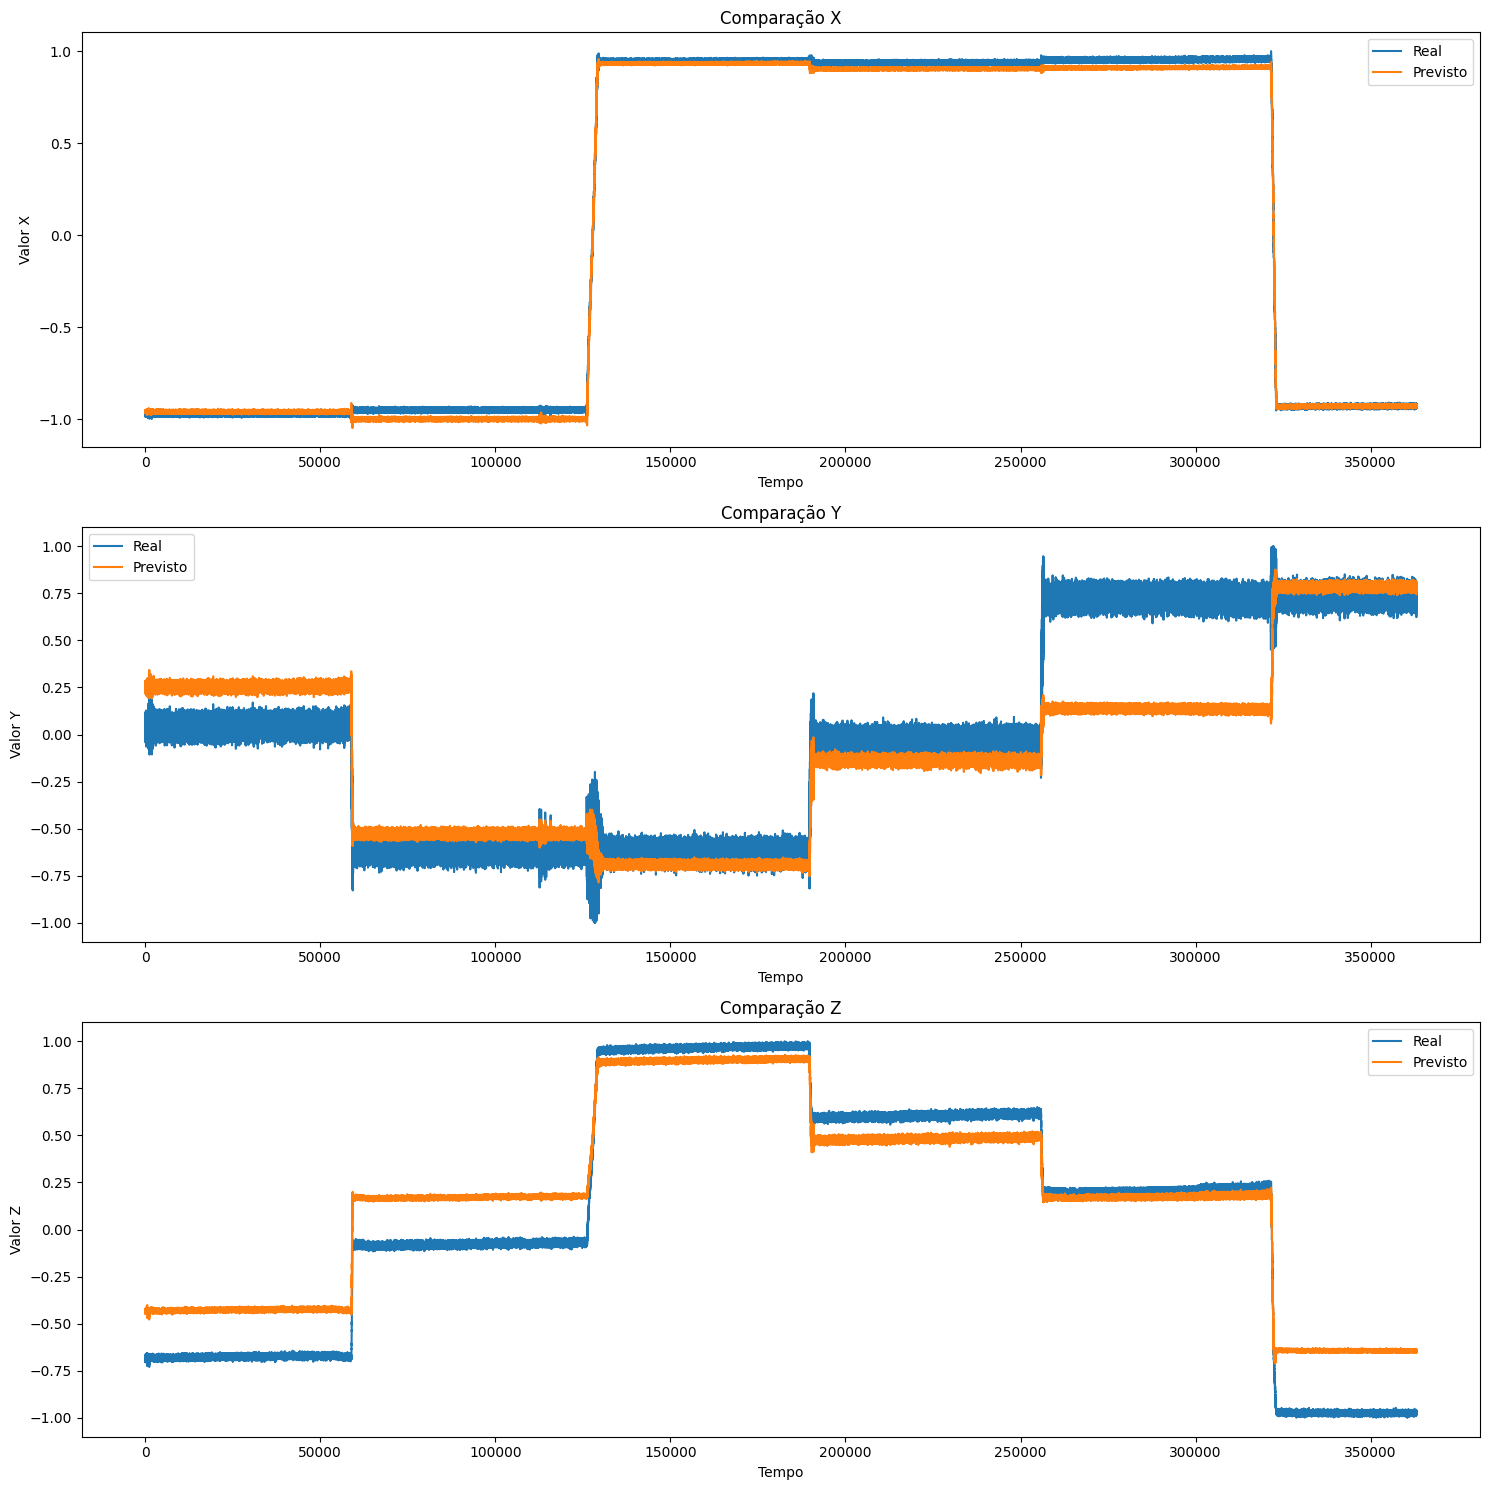

In [39]:
# Definindo as dimensões
dims = ['X', 'Y', 'Z']

plt.figure(figsize=(15, 15))

# Criando um gráfico para cada dimensão
for i, dim in enumerate(dims):
    plt.subplot(3, 1, i+1)
    plt.plot(X_test1_1[:, -1, i], label='Real')
    plt.plot(predicted1_1[:, i], label='Previsto')
    plt.title(f'Comparação {dim}')
    plt.xlabel('Tempo')
    plt.ylabel(f'Valor {dim}')
    plt.legend()

plt.tight_layout()
plt.show()

### Plotando desnormalizado

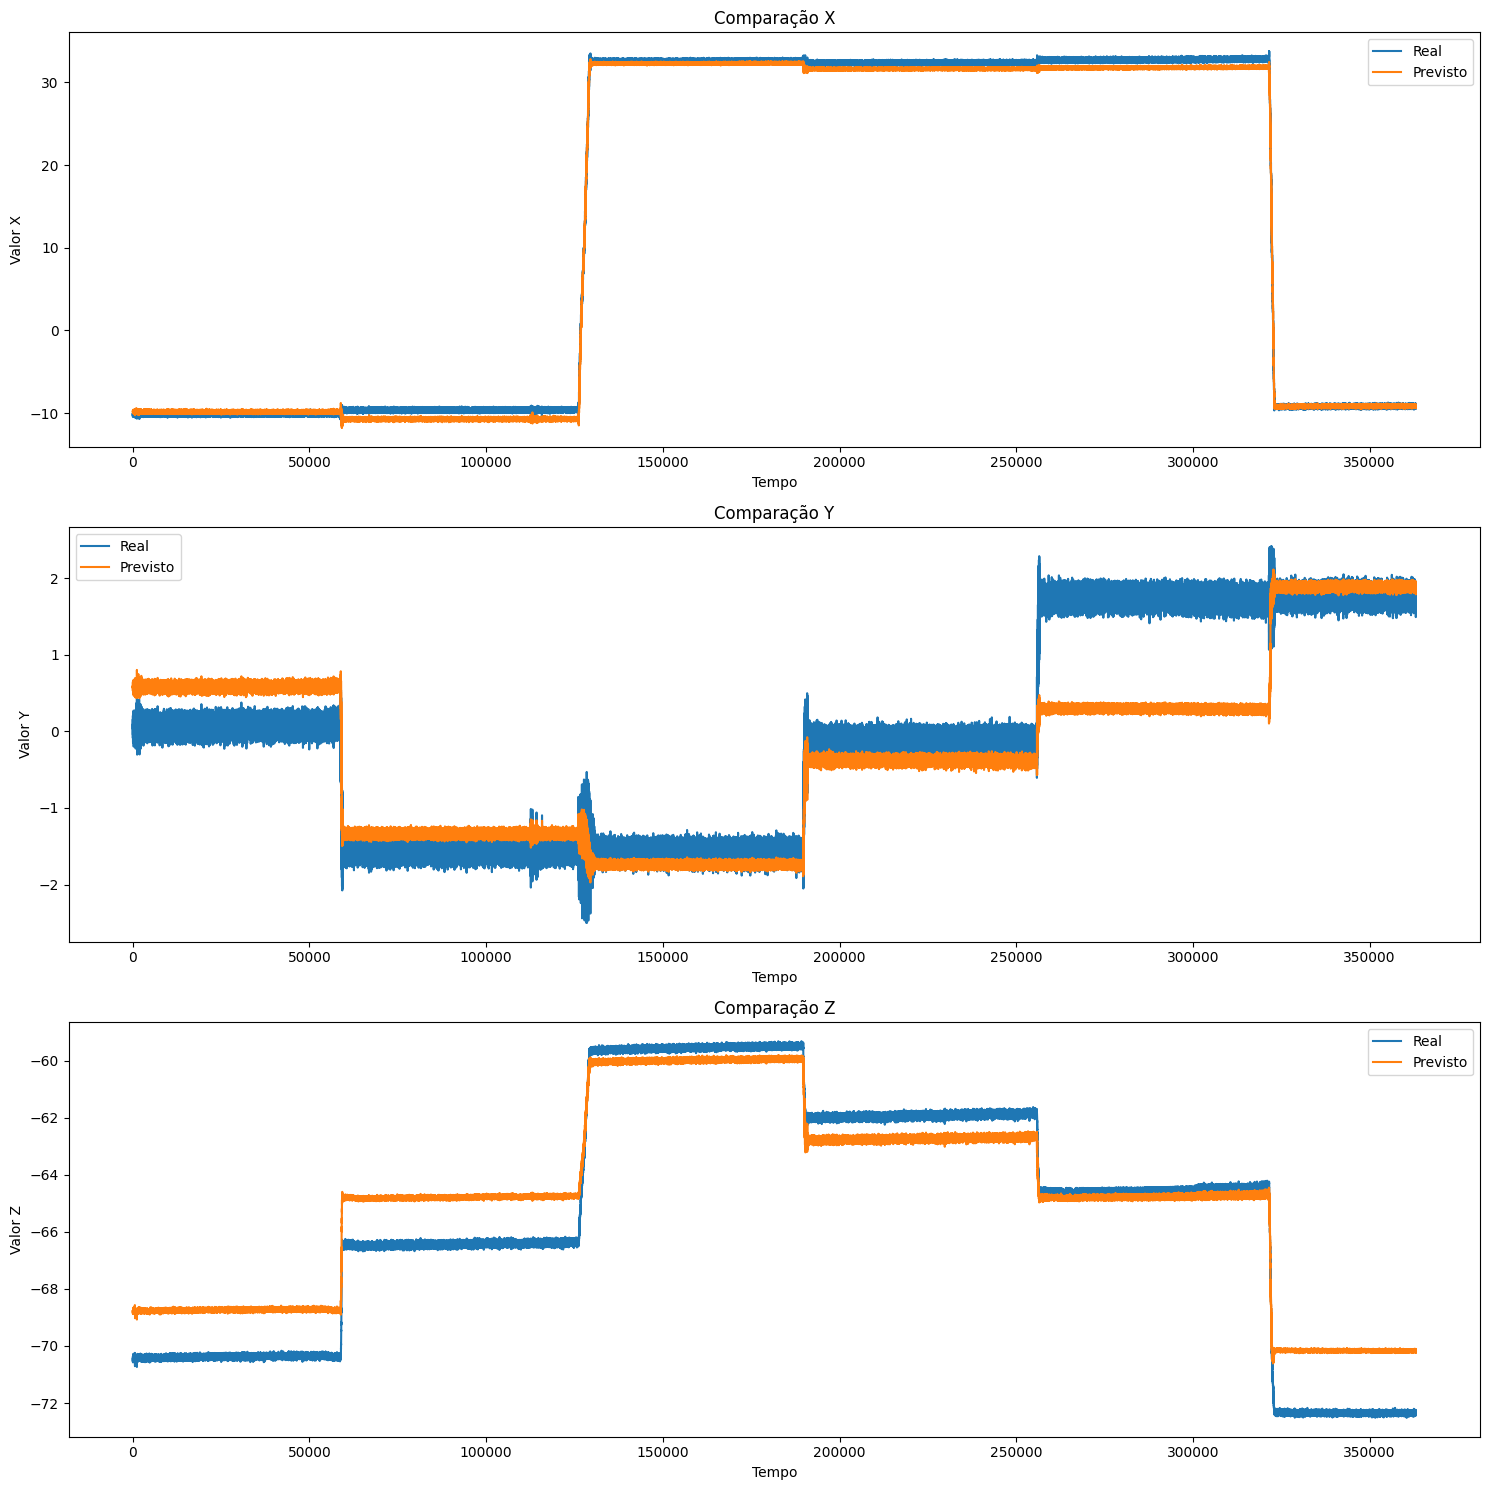

In [40]:
dims = ['X', 'Y', 'Z']

plt.figure(figsize=(15, 15))

for i, dim in enumerate(dims):
    plt.subplot(3, 1, i+1)

    # Desnormalizando os valores reais e previstos
    real_denorm = scalers_tuple[dim].inverse_transform(X_test1_1[:, -1, i].reshape(-1, 1)).flatten()
    pred_denorm = scalers_tuple[dim].inverse_transform(predicted1_1[:, i].reshape(-1, 1)).flatten()

    plt.plot(real_denorm, label='Real')
    plt.plot(pred_denorm, label='Previsto')
    plt.title(f'Comparação {dim}')
    plt.xlabel('Tempo')
    plt.ylabel(f'Valor {dim}')
    plt.legend()

plt.tight_layout()
plt.show()

### Mean Squared Error e $R^2$ nos novos dados do Sensor 1 ******************

In [41]:
mse = mean_squared_error(y_test1_1, predicted1_1)
r2 = r2_score(y_test1_1, predicted1_1)

MSE_R2 = {
    "MSE: ":mse,
    "R2: ": r2
}
# Salvar os hiperparâmetros em um arquivo JSON
model_folder = "models_GY87"
config_path = os.path.join(model_folder, "2.Mean Squared Error e R2.NewData.json")
with open(config_path, "w") as f:
    json.dump(MSE_R2, f, indent=4)

print(f"Hiperparâmetros salvos em {config_path}")

print("MSE:", mse)
print("R²:", r2)

Hiperparâmetros salvos em models_GY87/2.Mean Squared Error e R2.NewData.json
MSE: 0.03793782806361039
R²: 0.8841262817584257


# Estabilizando o dados estaticos (POC)

In [42]:
# Suponha que df_novos_dados seja o DataFrame com os novos dados do sensor
# e que o modelo já tenha sido carregado e esteja pronto para uso
# Carregar os novos dados do sensor
file_path = './Dados/sensor_data GY-87_3.txt'  # Substitua pelo caminho correto do arquivo
# file_path = './Dados/sensor_data GY-87_1.1.txt'  # Substitua pelo caminho correto do arquivo

df_novos_dados = pd.read_csv(file_path, header=None, names=['X', 'Y', 'Z'])

df_novos_dados_cleaned = remove_outliers_rolling_mad(df_novos_dados, ['X', 'Y', 'Z'], window=5000, k=6)
# Normalizar os novos dados
df_novos_dados_scaled = pd.DataFrame(normalizar_eixos_independente(df_novos_dados_cleaned)[0], columns=df_novos_dados_cleaned.columns)

# Preparar os dados para o modelo
values_novos_dados = df_novos_dados_scaled.values
X_novos_dados = []
for i in range(len(values_novos_dados) - n_timesteps):
    X_novos_dados.append(values_novos_dados[i:(i + n_timesteps)])
X_novos_dados = np.array(X_novos_dados)

# Fazer previsões com o modelo para cada sequência
predicted_novos_dados = modelo_carregado.predict(X_novos_dados)


9862/9862 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step


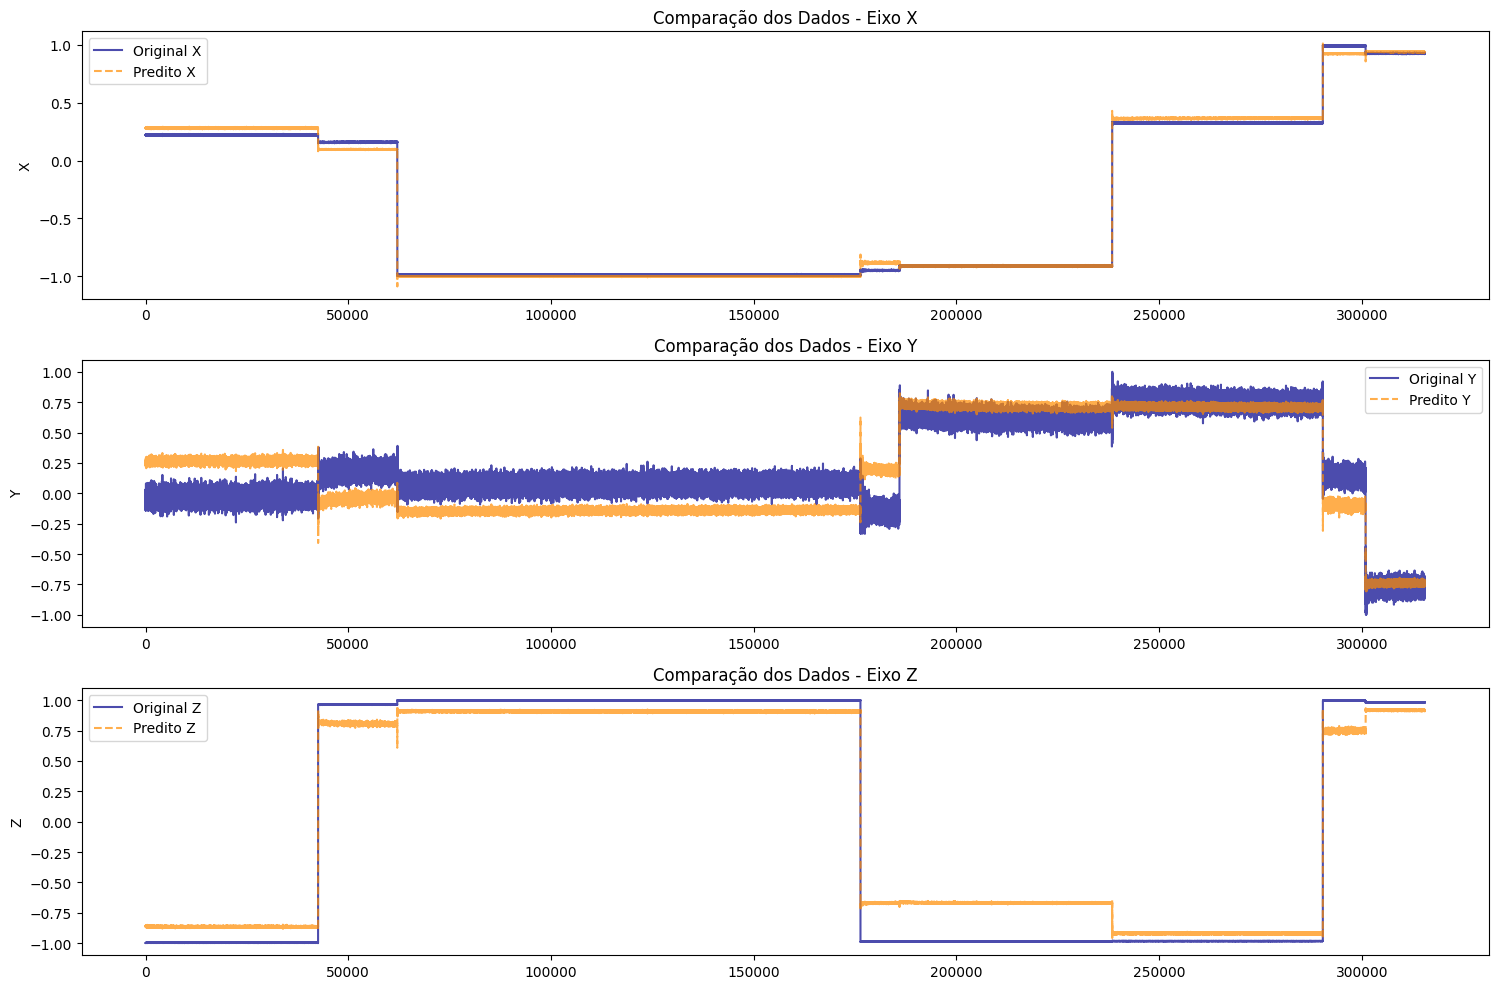

In [43]:
# Plotar comparações entre os dados originais e preditos para cada eixo
def plot_comparacao_original_predito(values_novos_dados, predicted_novos_dados, n_timesteps):
    valores_originais = values_novos_dados[n_timesteps:]  # alinhar com predição

    plt.figure(figsize=(15, 10))

    # Eixo X
    plt.subplot(3, 1, 1)
    plt.plot(valores_originais[:, 0], label='Original X', color='darkblue', alpha=0.7)
    plt.plot(predicted_novos_dados[:, 0], label='Predito X', color='darkorange', alpha=0.7, linestyle='--')
    plt.title('Comparação dos Dados - Eixo X')
    plt.ylabel('X')
    plt.legend()

    # Eixo Y
    plt.subplot(3, 1, 2)
    plt.plot(valores_originais[:, 1], label='Original Y', color='darkblue', alpha=0.7)
    plt.plot(predicted_novos_dados[:, 1], label='Predito Y', color='darkorange', alpha=0.7, linestyle='--')
    plt.title('Comparação dos Dados - Eixo Y')
    plt.ylabel('Y')
    plt.legend()

    # Eixo Z
    plt.subplot(3, 1, 3)
    plt.plot(valores_originais[:, 2], label='Original Z', color='darkblue', alpha=0.7)
    plt.plot(predicted_novos_dados[:, 2], label='Predito Z', color='darkorange', alpha=0.7, linestyle='--')
    plt.title('Comparação dos Dados - Eixo Z')
    plt.ylabel('Z')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_comparacao_original_predito(values_novos_dados, predicted_novos_dados, n_timesteps)

Iniciando simulação de correção em tempo real com dados consistentes...
Simulação concluída. Gerando gráfico...


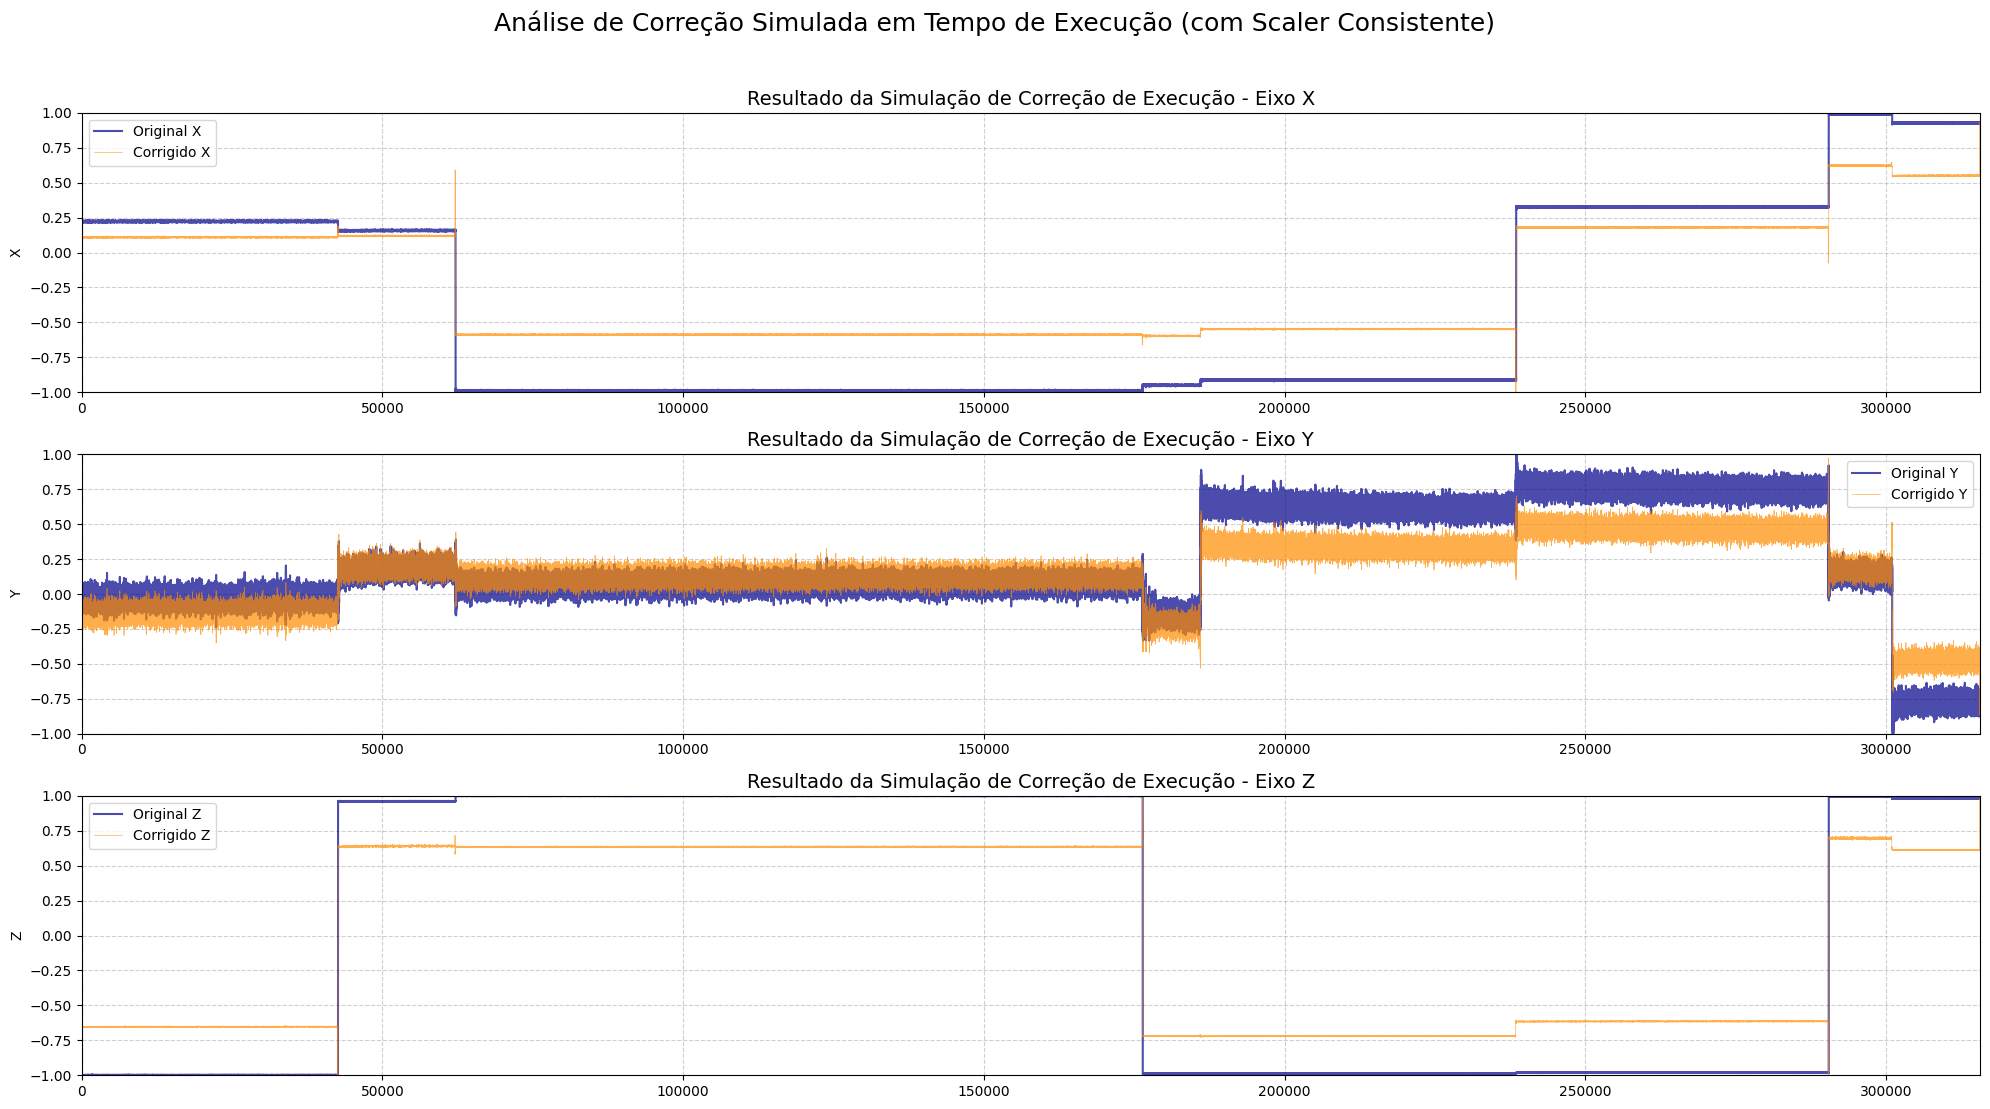

In [44]:
# SIMULAÇÃO EM TEMPO REAL (nosso código, agora usando os dados corretos) ---
fator_correcao = 0.4

print("Iniciando simulação de correção em tempo real com dados consistentes...")

dados_corrigidos_tempo_real = np.copy(values_novos_dados)

for i in range(len(predicted_novos_dados)):
    # indice_real_atual = i + n_timesteps
    # valor_real_atual = values_novos_dados[indice_real_atual]
    # predicao_do_ruido_atual = predicted_novos_dados[i]
    
    # valor_corrigido = valor_real_atual - predicao_do_ruido_atual * 1.0

    # dados_corrigidos_tempo_real[indice_real_atual] = valor_corrigido
    valor_corrigido = values_novos_dados[i] - predicted_novos_dados[i] * fator_correcao
    
    dados_corrigidos_tempo_real[i] = valor_corrigido

print("Simulação concluída. Gerando gráfico...")

# --- PLOTAGEM FINAL ---

df_original_full = pd.DataFrame(values_novos_dados, columns=['X', 'Y', 'Z'])
df_corrigido_simulado = pd.DataFrame(dados_corrigidos_tempo_real, columns=['X', 'Y', 'Z'])

plt.figure(figsize=(20, 12))
for i, eixo in enumerate(['X', 'Y', 'Z']):
    plt.subplot(3, 1, i + 1)
    plt.plot(df_original_full.index, df_original_full[eixo], label=f'Original {eixo}', alpha=0.7, color='darkblue')
    plt.plot(df_corrigido_simulado.index, df_corrigido_simulado[eixo], label=f'Corrigido {eixo}', linestyle='-', alpha=0.7, color='darkorange', linewidth=0.5)
    plt.title(f'Resultado da Simulação de Correção de Execução - Eixo {eixo}', fontsize=14)
    plt.ylabel(eixo)
    plt.ylim(-1, 1)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim(0, len(df_original_full))
plt.suptitle('Análise de Correção Simulada em Tempo de Execução (com Scaler Consistente)', fontsize=18, y=0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

Iniciando simulação (Cumulativa de Erro de Variação)


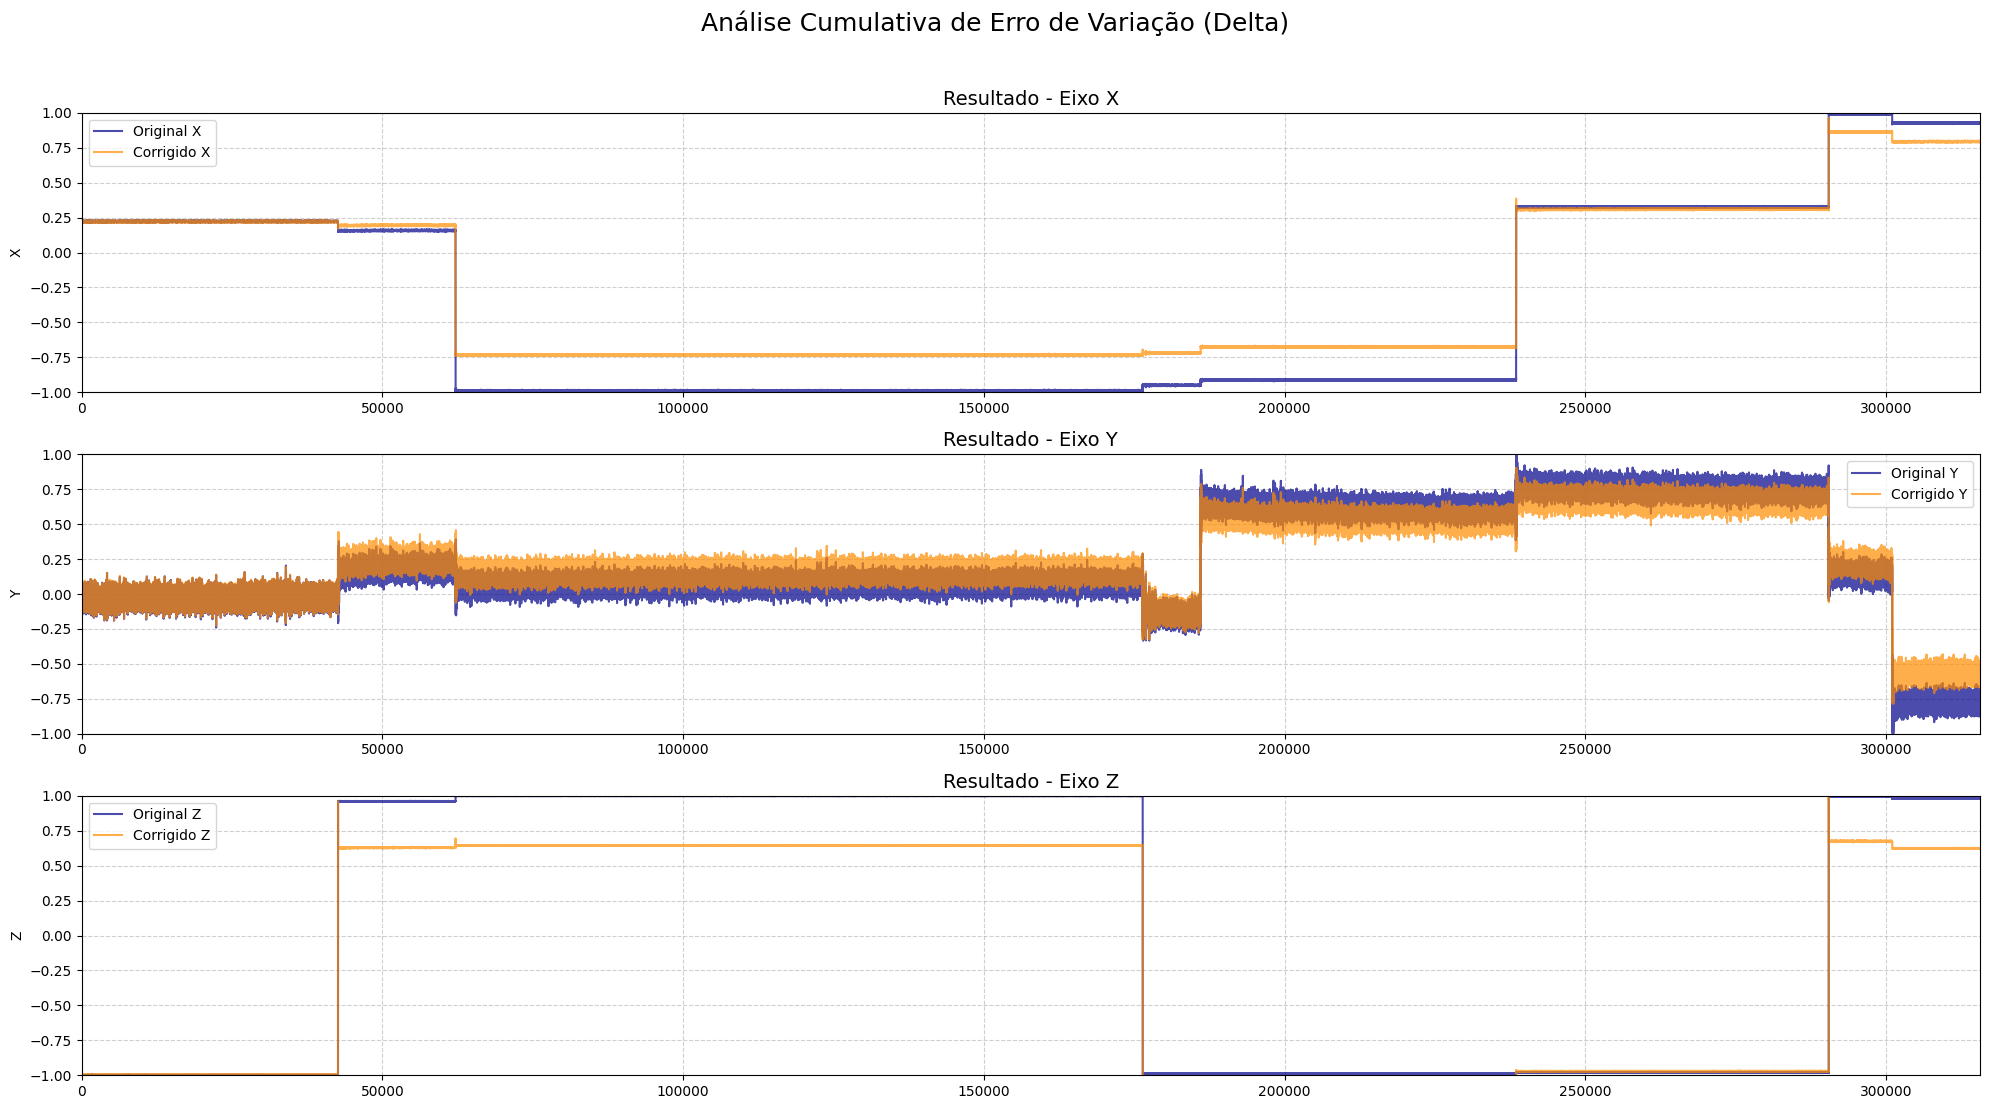

In [45]:
print("Iniciando simulação (Cumulativa de Erro de Variação)")

fator_correcao = 0.2

# Alinhar os dados
min_len = min(len(predicted_novos_dados), len(values_novos_dados[n_timesteps:]))
original_base = values_novos_dados[n_timesteps:][:min_len]
predicted_base = predicted_novos_dados[:min_len]

# Inicializar o array de resultados
dados_corrigidos_logica2 = np.zeros_like(original_base)

# Ponto de partida: O primeiro valor corrigido é o primeiro valor original
dados_corrigidos_logica2[0] = original_base[0]

# Loop de simulação
for i in range(1, len(original_base)):
    # Variação (delta) do sinal original no último passo
    delta_original = original_base[i] - original_base[i-1]
    
    # Variação (delta) do sinal predito no último passo
    delta_predito = predicted_base[i] - predicted_base[i-1]
    
    # O erro na variação é a diferença entre os deltas
    erro_de_variacao = delta_original - delta_predito * fator_correcao
    
    # O novo valor corrigido é o anterior mais o erro de variação
    dados_corrigidos_logica2[i] = dados_corrigidos_logica2[i-1] + erro_de_variacao

# --- Preparar para plotagem ---
dados_finais_para_plotar = np.full_like(values_novos_dados, np.nan)
inicio_plot = n_timesteps
fim_plot = inicio_plot + len(dados_corrigidos_logica2)
dados_finais_para_plotar[inicio_plot:fim_plot, :] = dados_corrigidos_logica2

df_original_full = pd.DataFrame(values_novos_dados, columns=['X', 'Y', 'Z'])
df_corrigido_simulado = pd.DataFrame(dados_finais_para_plotar, columns=['X', 'Y', 'Z'])

# --- PLOTAGEM ---
plt.figure(figsize=(20, 12))
# ... (código de plotagem idêntico ao anterior) ...
for i, eixo in enumerate(['X', 'Y', 'Z']):
    plt.subplot(3, 1, i + 1)
    plt.plot(df_original_full.index, df_original_full[eixo], label=f'Original {eixo}', alpha=0.7, color='darkblue')
    plt.plot(df_corrigido_simulado.index, df_corrigido_simulado[eixo], label=f'Corrigido {eixo}', linestyle='-', alpha=0.7, color='darkorange', linewidth=1.5)
    plt.title(f'Resultado - Eixo {eixo}', fontsize=14)
    plt.ylabel(eixo)
    plt.ylim(-1, 1)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim(0, len(df_original_full))
plt.suptitle('Análise Cumulativa de Erro de Variação (Delta)', fontsize=18, y=0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show() 

# _________________________________________________________________________________________________
# Teste em um conjunto de dados do Sensor 2

Carregando Dados Sensor 2

In [46]:
# Carregar os dados do arquivo
file_path2 = './Dados/sensor_data GY-87_2.txt'
df2 = pd.read_csv(file_path2, header=None, names=['X', 'Y', 'Z'])
print(len(df2))
print(df2.head())

679677
          X         Y           Z
0  2.074969 -1.760471 -156.014709
1  2.016577 -1.740992 -155.957504
2  2.081915 -1.768907 -155.949951
3  1.988364 -1.707933 -155.927551
4  2.007283 -1.757901 -155.936005


#### Retirando Outliers

In [47]:
# se k menor = mais agressivo
df2_cleaned = remove_outliers_rolling_mad(df2, ['X','Y','Z'], window=5000, k=6)
# Exibir as primeiras linhas do DataFrame limpo
print(df2_cleaned.head())
df2=df2_cleaned

             X         Y           Z
5000  2.035090 -1.797416 -156.061478
5001  2.024974 -1.734467 -156.017868
5002  2.006305 -1.769469 -156.019836
5003  2.073869 -1.777356 -155.961670
5004  2.072165 -1.784499 -155.941757


Normalizando os dados

In [48]:
df2_scaled = pd.DataFrame(normalizar_eixos_independente(df2_cleaned)[0], columns=df2_cleaned.columns)

print(df2_scaled.head())

          X         Y         Z
0  0.372010 -0.333354 -0.998923
1  0.371208 -0.212722 -0.998680
2  0.369730 -0.279798 -0.998691
3  0.375080 -0.294913 -0.998367
4  0.374945 -0.308600 -0.998256


Preparando os dados de Teste do Sensor 2

In [49]:
# Supondo que test_data seja seu DataFrame de teste normalizado
# Convertendo para numpy array
values_test2 = df2_scaled.values

# Reformatando os dados para a entrada LSTM
X_test2, y_test2 = [], []
for i in range(len(values_test2) - n_timesteps):
    X_test2.append(values_test2[i:(i + n_timesteps), :])
    y_test2.append(values_test2[i + n_timesteps, :])
X_test2, y_test2 = np.array(X_test2), np.array(y_test2)

# Agora X_test e y_test estão prontos para serem usados para testar o modelo

Fazendo a predição

In [50]:
predicted2 = modelo_carregado.predict(X_test2)

20871/20871 ━━━━━━━━━━━━━━━━━━━━ 60s 3ms/step


Plotando os resultados

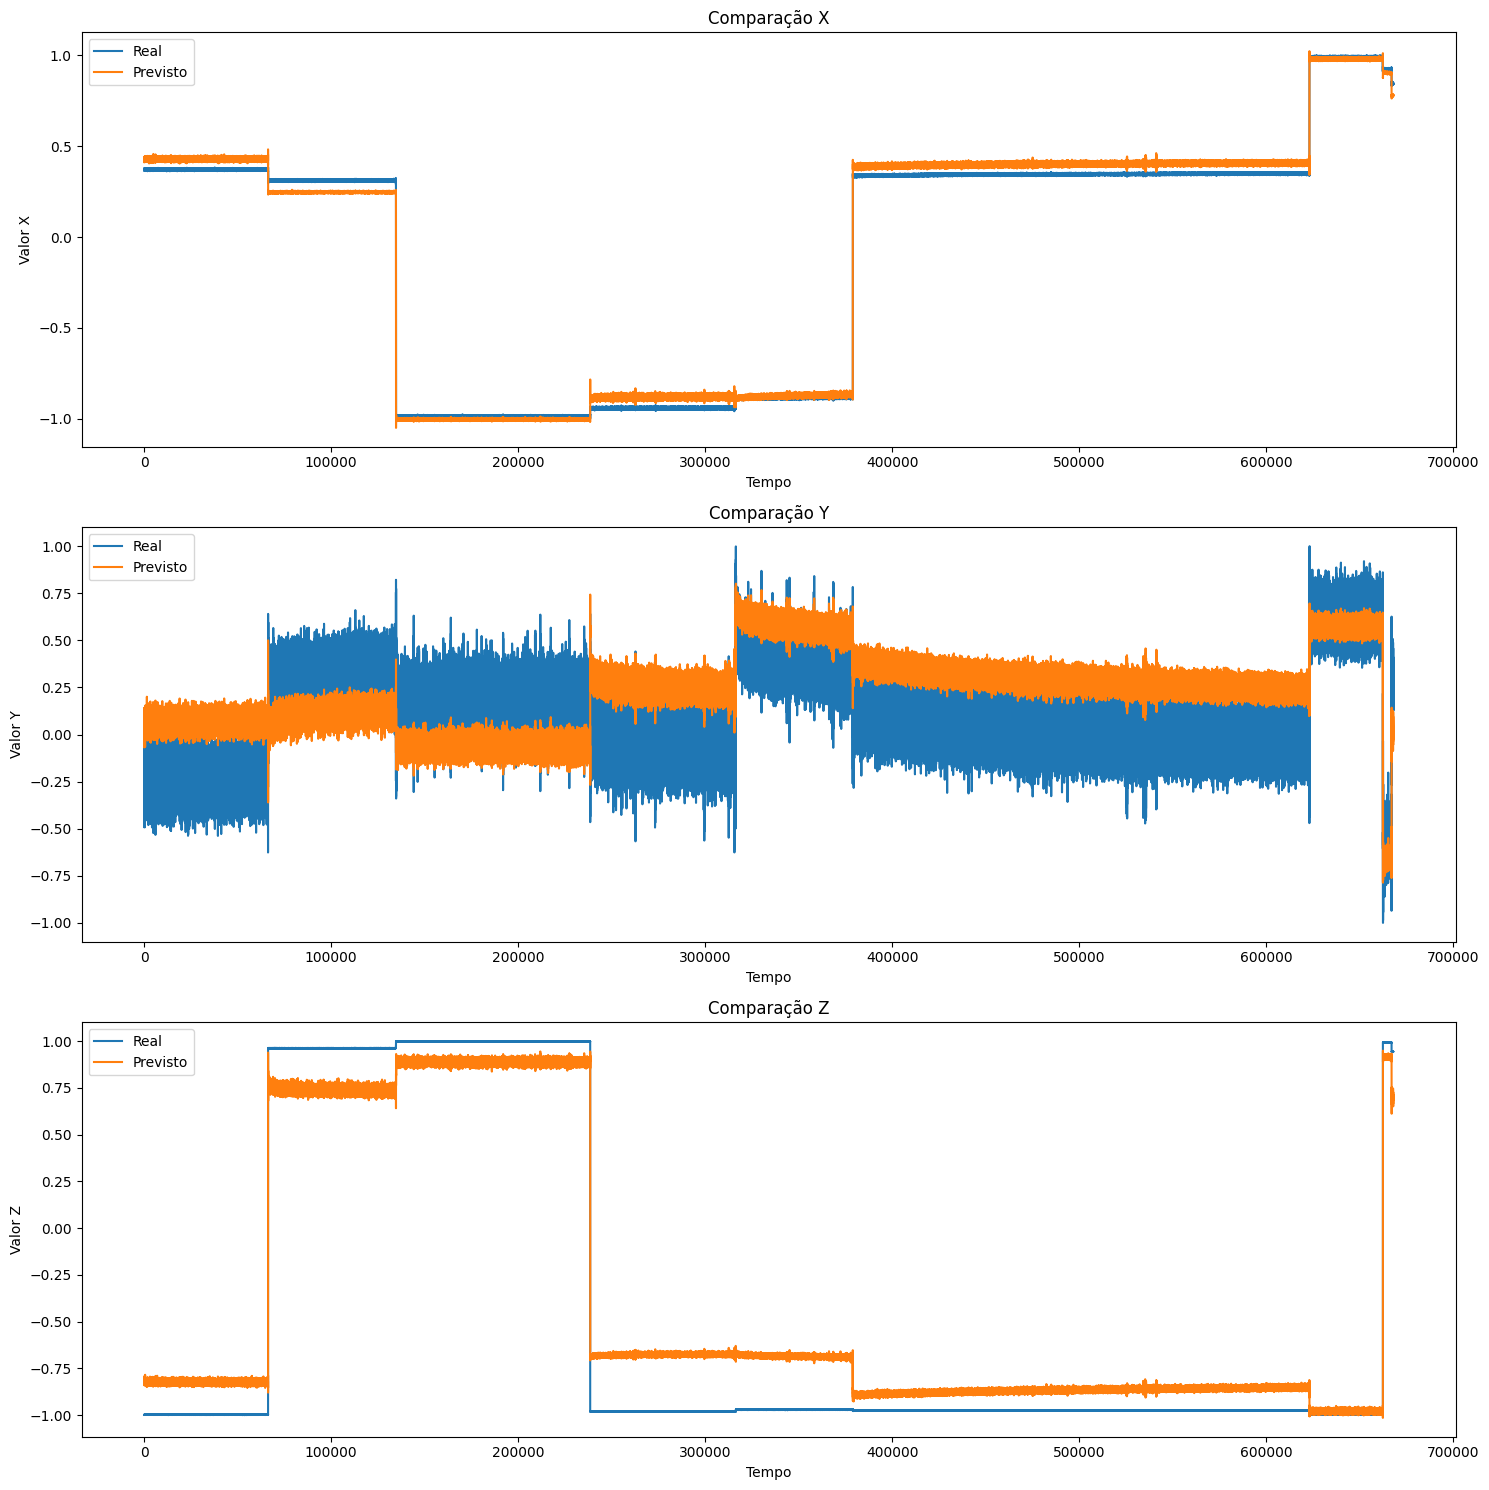

In [51]:
# Definindo as dimensões
dims = ['X', 'Y', 'Z']

plt.figure(figsize=(15, 15))

# Criando um gráfico para cada dimensão
for i, dim in enumerate(dims):
    plt.subplot(3, 1, i+1)
    plt.plot(X_test2[:, -1, i], label='Real')
    plt.plot(predicted2[:, i], label='Previsto')
    plt.title(f'Comparação {dim}')
    plt.xlabel('Tempo')
    plt.ylabel(f'Valor {dim}')
    plt.legend()

plt.tight_layout()
plt.show()

### Plotando desnormalizado

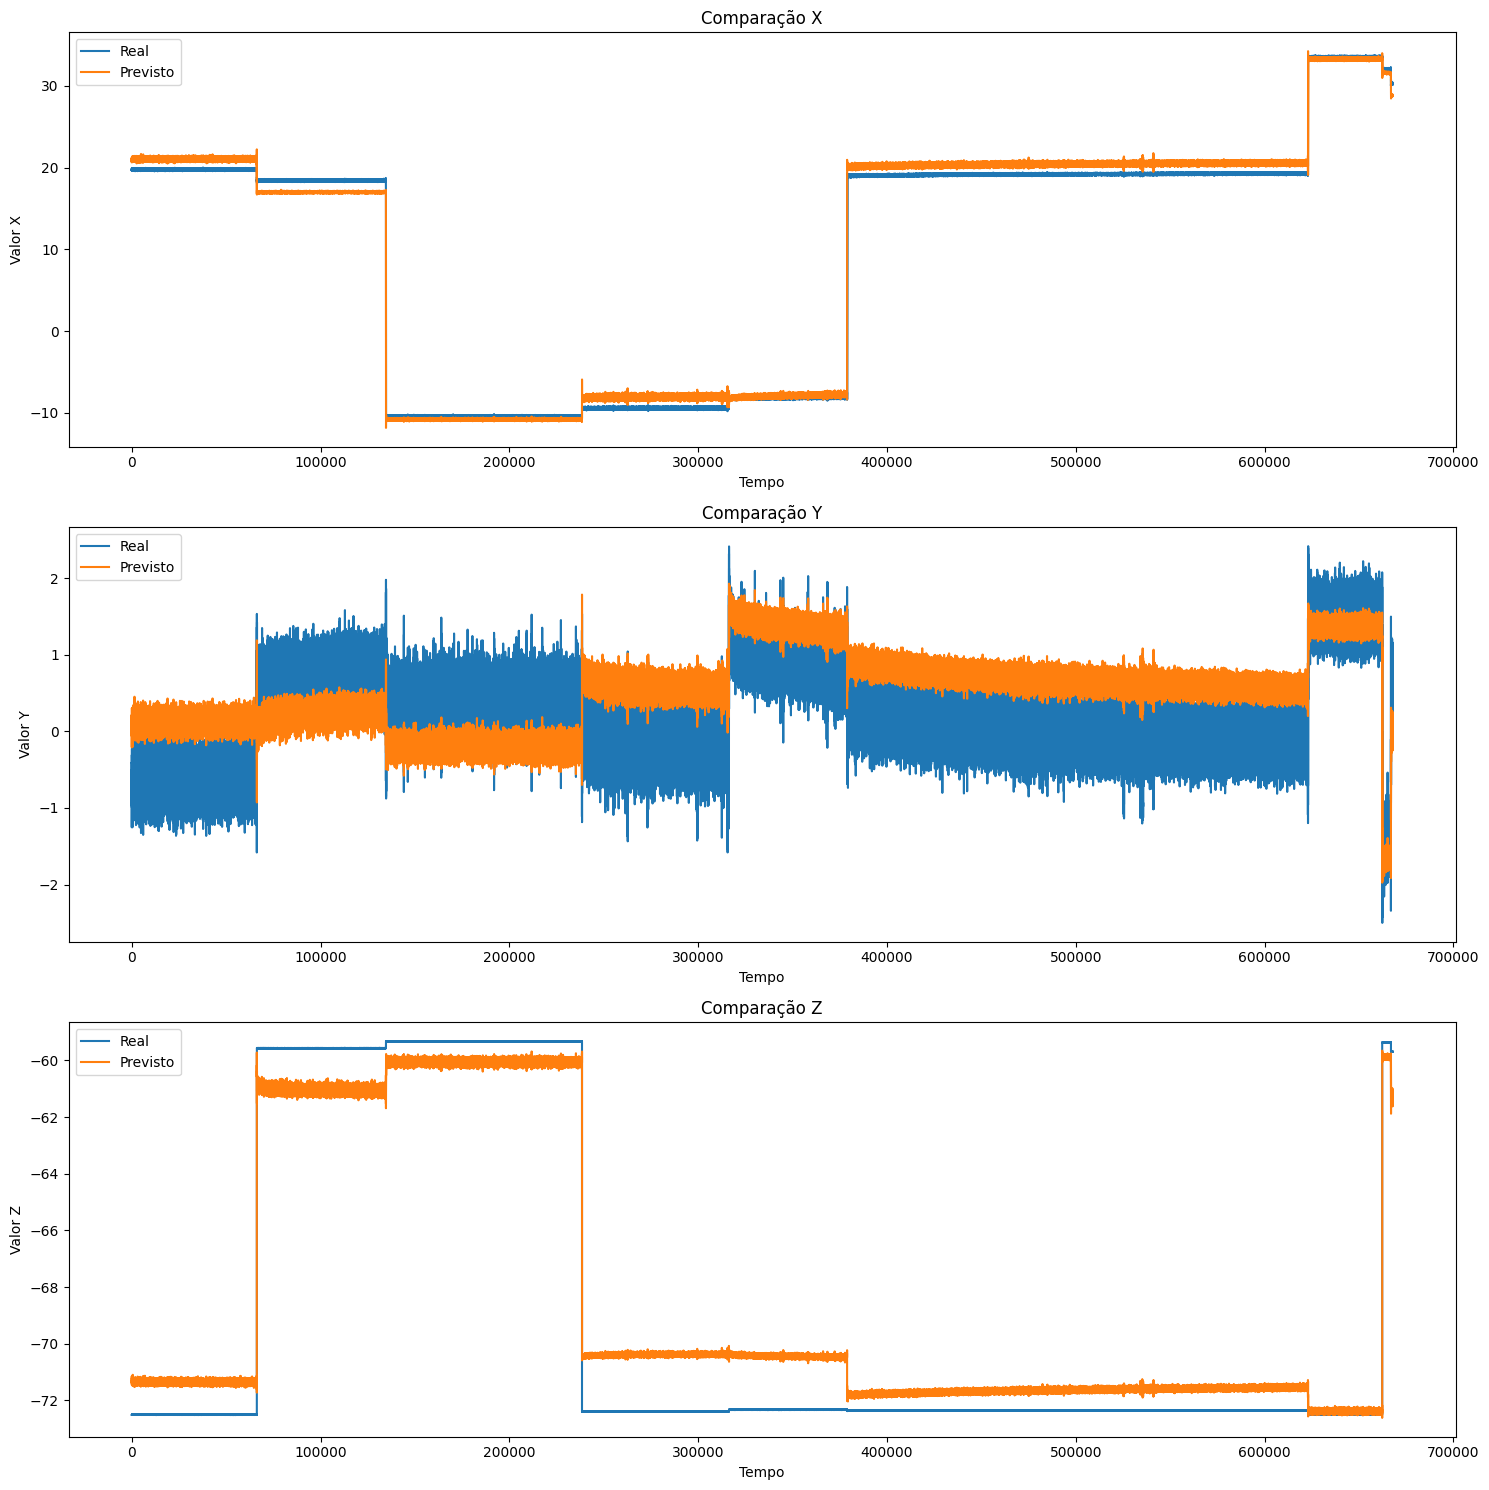

In [52]:
dims = ['X', 'Y', 'Z']

plt.figure(figsize=(15, 15))

for i, dim in enumerate(dims):
    plt.subplot(3, 1, i+1)

    # Desnormalizando os valores reais e previstos
    real_denorm = scalers_tuple[dim].inverse_transform(X_test2[:, -1, i].reshape(-1, 1)).flatten()
    pred_denorm = scalers_tuple[dim].inverse_transform(predicted2[:, i].reshape(-1, 1)).flatten()

    plt.plot(real_denorm, label='Real')
    plt.plot(pred_denorm, label='Previsto')
    plt.title(f'Comparação {dim}')
    plt.xlabel('Tempo')
    plt.ylabel(f'Valor {dim}')
    plt.legend()

plt.tight_layout()
plt.show()


## Mean Squared Error e $R^2$ no Sensor 2

In [53]:
mse = mean_squared_error(y_test2, predicted2)
r2 = r2_score(y_test2, predicted2)

MSE_R2 = {
    "MSE: ":mse,
    "R2: ": r2
}
# Salvar os hiperparâmetros em um arquivo JSON
model_folder = "models_GY87"
config_path = os.path.join(model_folder, "3.Mean Squared Error e R2.Sensor2.json")
with open(config_path, "w") as f:
    json.dump(MSE_R2, f, indent=4)

print(f"Hiperparâmetros salvos em {config_path}")

print("MSE:", mse)
print("R²:", r2)

Hiperparâmetros salvos em models_GY87/3.Mean Squared Error e R2.Sensor2.json
MSE: 0.03566226751234259
R²: 0.5699399516506932


# ________________________________________________________________________________________________
# Teste em um conjunto de dados do Sensor 3

Carregando Dados Sensor 2

In [54]:
# Carregar os dados do arquivo
file_path3 = './Dados/sensor_data GY-87_3.txt'
df3 = pd.read_csv(file_path3, header=None, names=['X', 'Y', 'Z'])
print(len(df3))
print(df3.head())

326874
          X         Y           Z
0  0.224601  0.665587 -152.545502
1  0.197612  0.691833 -152.660934
2  0.253607  0.761412 -152.565216
3  0.168086  0.728715 -152.653824
4  0.161009  0.711798 -152.691010


### Retirando Outliers

In [55]:
# se k menor = mais agressivo
df3_cleaned = remove_outliers_rolling_mad(df3, ['X','Y','Z'], window=5000, k=6)
# Exibir as primeiras linhas do DataFrame limpo
print(df3_cleaned.head())
df3=df3_cleaned

             X         Y           Z
5000  0.111091  0.784004 -152.576538
5001  0.165380  0.739138 -152.526550
5002  0.093191  0.683545 -152.524918
5003  0.142345  0.733310 -152.680298
5004  0.105950  0.713201 -152.757645


Normalizando os dados

In [56]:
df3_scaled = pd.DataFrame(normalizar_eixos_independente(df3)[0], columns=df3.columns)

print(df3_scaled.head())

          X         Y         Z
0  0.220174 -0.009078 -0.998056
1  0.223513 -0.060716 -0.997778
2  0.219073 -0.124700 -0.997769
3  0.222096 -0.067424 -0.998633
4  0.219857 -0.090568 -0.999063


Preparando os dados de Teste do Sensor 3

In [57]:
# Supondo que test_data seja seu DataFrame de teste normalizado
# Convertendo para numpy array
values_test3 = df3_scaled.values

# Reformatando os dados para a entrada LSTM
X_test3, y_test3 = [], []
for i in range(len(values_test3) - n_timesteps):
    X_test3.append(values_test3[i:(i + n_timesteps), :])
    y_test3.append(values_test3[i + n_timesteps, :])
X_test3, y_test3 = np.array(X_test3), np.array(y_test3)

# Agora X_test e y_test estão prontos para serem usados para testar o modelo

Fazendo a predição

In [58]:
predicted3 = modelo_carregado.predict(X_test3)

9862/9862 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step


Plotando os resultados

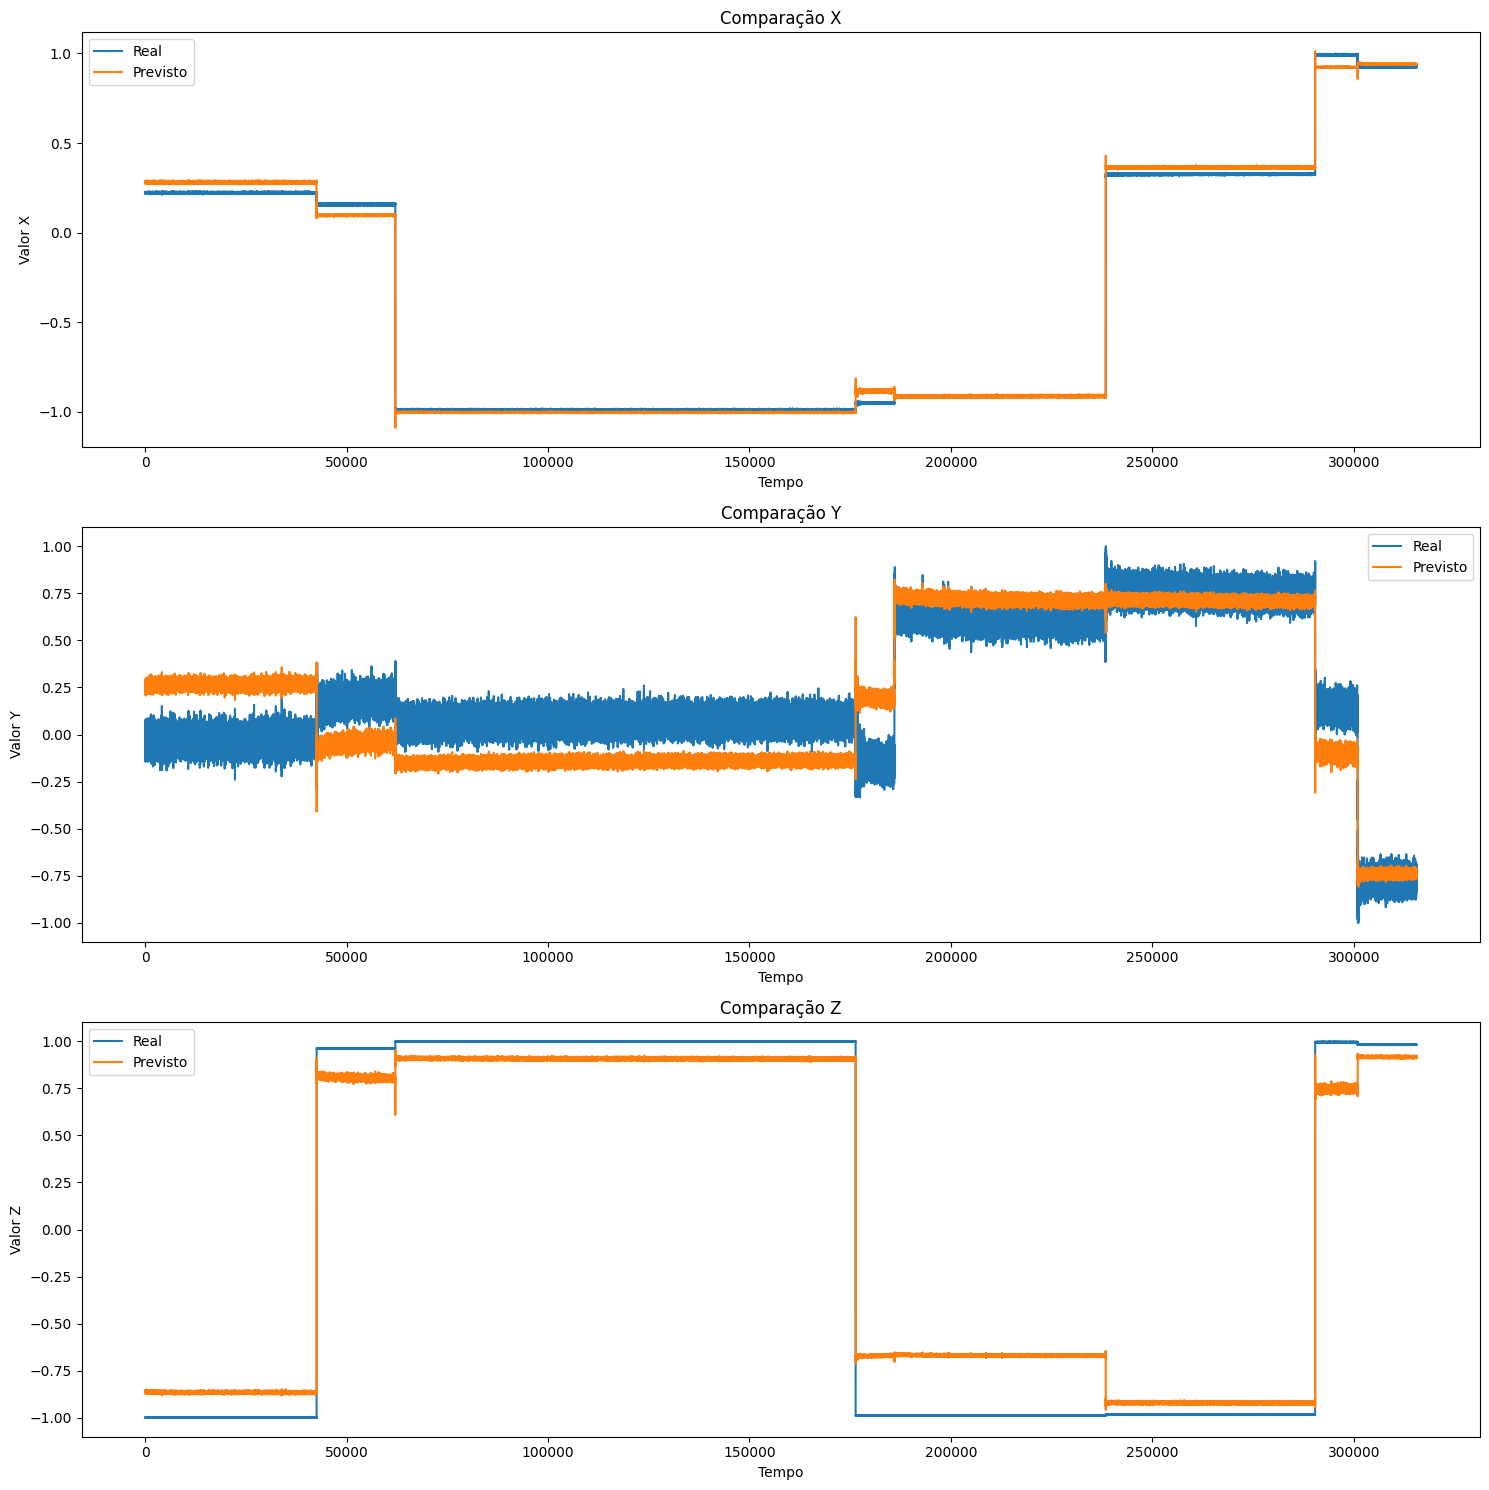

In [59]:
# Definindo as dimensões
dims = ['X', 'Y', 'Z']

plt.figure(figsize=(15, 15))

# Criando um gráfico para cada dimensão
for i, dim in enumerate(dims):
    plt.subplot(3, 1, i+1)
    plt.plot(X_test3[:, -1, i], label='Real')
    plt.plot(predicted3[:, i], label='Previsto')
    plt.title(f'Comparação {dim}')
    plt.xlabel('Tempo')
    plt.ylabel(f'Valor {dim}')
    plt.legend()

plt.tight_layout()
plt.show()

### Plotando desnormalizado

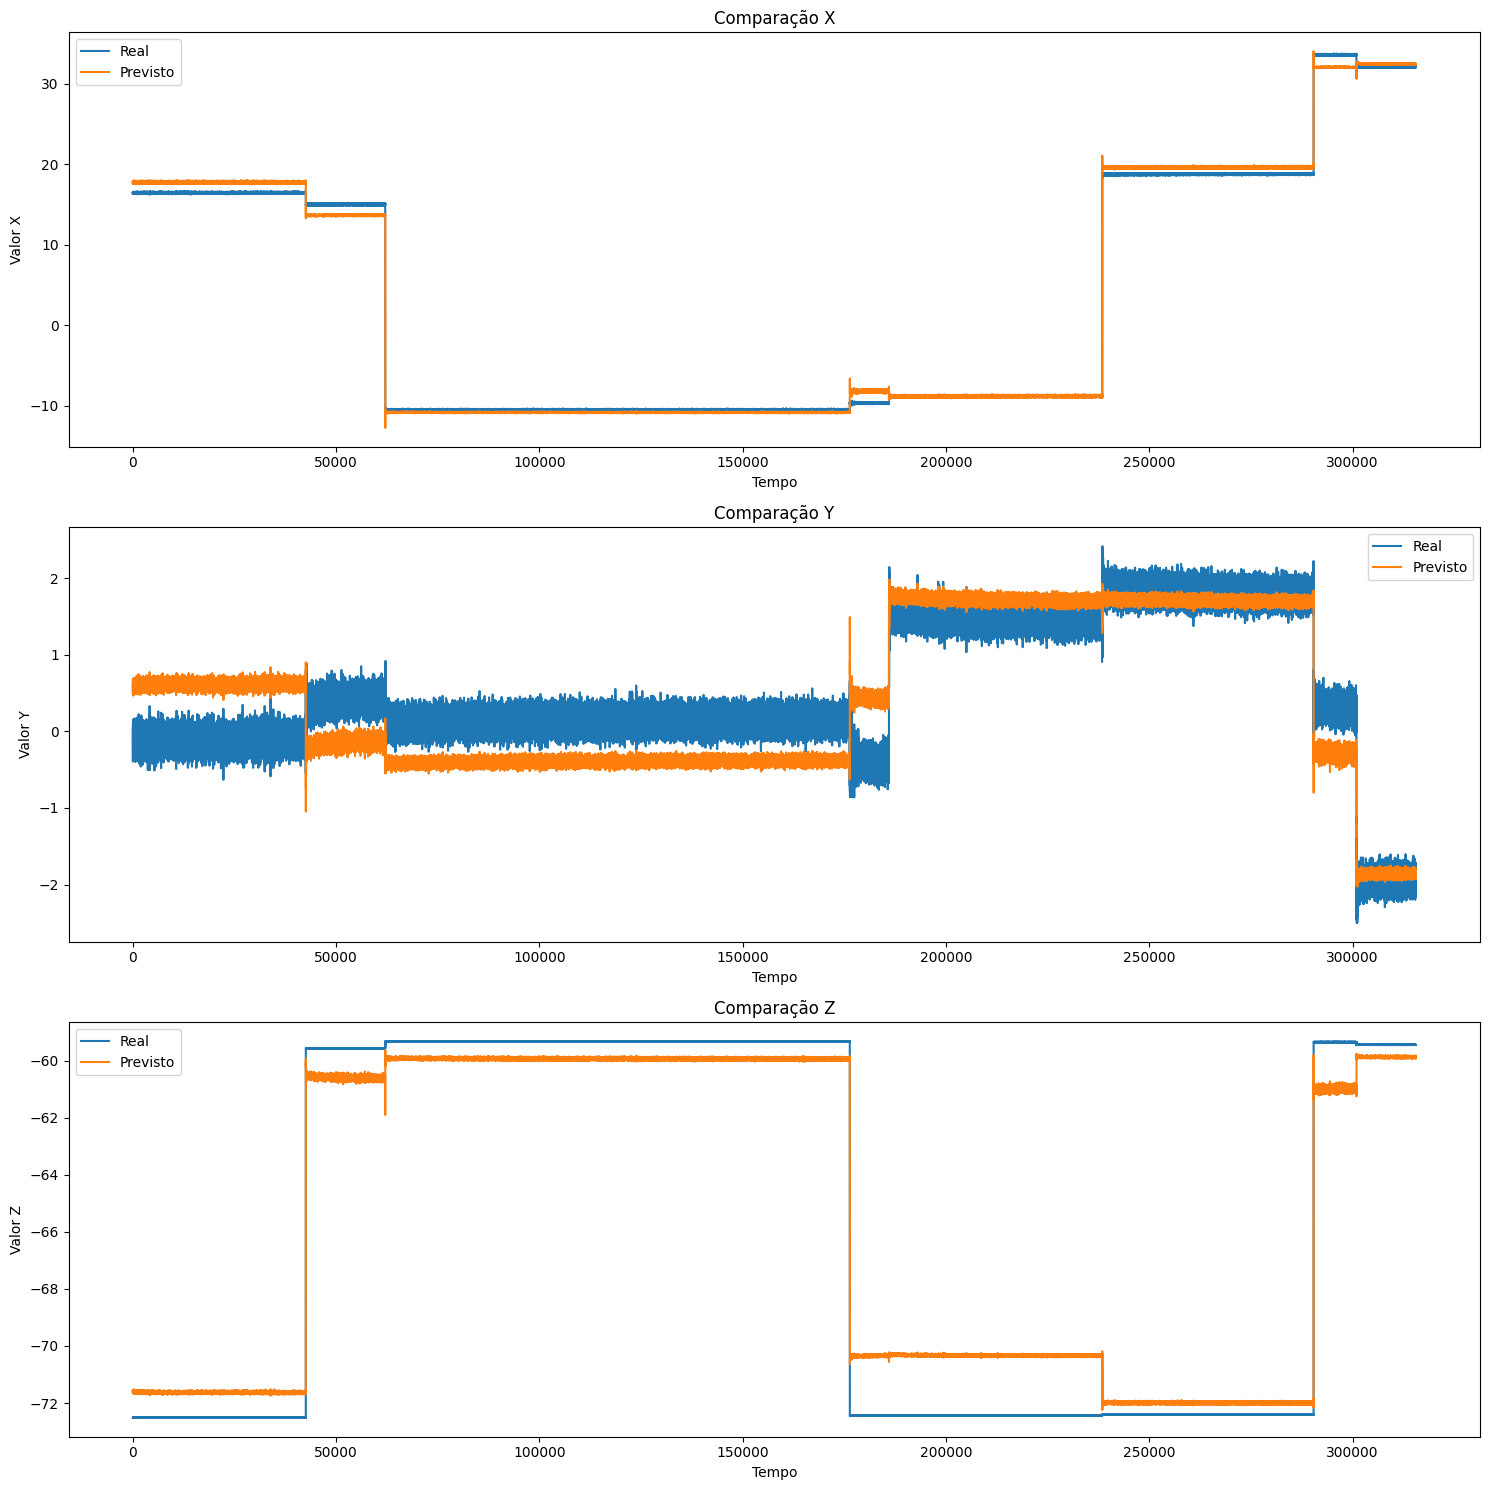

In [60]:
dims = ['X', 'Y', 'Z']

plt.figure(figsize=(15, 15))

for i, dim in enumerate(dims):
    plt.subplot(3, 1, i+1)

    # Desnormalizando os valores reais e previstos
    real_denorm = scalers_tuple[dim].inverse_transform(X_test3[:, -1, i].reshape(-1, 1)).flatten()
    pred_denorm = scalers_tuple[dim].inverse_transform(predicted3[:, i].reshape(-1, 1)).flatten()

    plt.plot(real_denorm, label='Real')
    plt.plot(pred_denorm, label='Previsto')
    plt.title(f'Comparação {dim}')
    plt.xlabel('Tempo')
    plt.ylabel(f'Valor {dim}')
    plt.legend()

plt.tight_layout()
plt.show()


## Mean Squared Error e $R^2$ no Sensor 3

In [ ]:
mse = mean_squared_error(y_test3, predicted3)
r2 = r2_score(y_test3, predicted3)

MSE_R2 = {
    "MSE: ":mse,
    "R2: ": r2
}
# Salvar os hiperparâmetros em um arquivo JSON
model_folder = "models_GY87"
config_path = os.path.join(model_folder, "4.Mean Squared Error e R2.Sensor3.json")
with open(config_path, "w") as f:
    json.dump(MSE_R2, f, indent=4)

print(f"Hiperparâmetros salvos em {config_path}")

print("MSE:", mse)
print("R²:", r2)

Hiperparâmetros salvos em models_GY87/4.Mean Squared Error e R2.Sensor3.json
MSE: 0.023834777941317397
R²: 0.8943421469279084


: 